# 02. EDA — 창원국가산단 업종별 산업·고용 전환진단

본분석은 KICOX의 **명목 생산액**과 고용을 전년동기 대비(YoY)로 비교한다. 국면은 두 지표의 변화 방향을 조합한 관측 상태이며 업종의 우열이나 원인을 뜻하지 않는다. PPI와 EIS는 본분석 뒤에서 해석 범위를 점검하는 보조자료로만 사용한다.

| 질문 | 확인할 내용 | 위치 |
|---|---|---|
| Q1 상태 | 같은 고용 변화에서도 명목 생산액 방향이 다른가? | Section 2 |
| Q2 규모 | 제조업 고용 변화에서 실제 인원 변화가 큰 업종은 어디인가? | Section 3 |
| Q3 시간 | 국면이 얼마나 이어지고 어떤 경로로 바뀌는가? | Section 4 |

Section 1은 Q1~Q3에 앞서 데이터 범위, 업종별 변화, 생산액과 고용의 관계를 탐색한다. 가동률·업체수, PPI, EIS, 업종별 진단카드와 최종 요약은 본분석 뒤에 둔다.

### 입력 및 실행

프로젝트 루트 또는 `notebooks` 디렉터리에서 실행한다. 입력 파일의 존재 여부와 계산 일관성은 Section 0에서 확인한다. 결과 그림은 `outputs/figures`, 표는 `outputs/tables`, 요약 보고서는 `outputs/report`에 저장한다.


## Section 0. 공통 분석 기준 · 데이터 점검

In [1]:
import warnings
import json
import hashlib
from IPython.display import display, Markdown
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore', message='This figure includes Axes')

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data' / 'processed' / 'kicox' / 'changwon_state_panel.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트의 data/processed/kicox/changwon_state_panel.csv가 필요합니다.')
DIR_PROC = ROOT / 'data' / 'processed'
DIR_FIG = ROOT / 'outputs' / 'figures'
DIR_TAB = ROOT / 'outputs' / 'tables'
DIR_REPORT = ROOT / 'outputs' / 'report'
DIR_FIG.mkdir(parents=True, exist_ok=True)
DIR_TAB.mkdir(parents=True, exist_ok=True)
DIR_REPORT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------- 한글 폰트
# 실행 환경(Windows / macOS / Linux)에 따라 설치된 한글 폰트가 다르므로 사용 가능한 첫 폰트를 쓴다.
import matplotlib.font_manager as fm
for _font in Path('/usr/local/share/fonts').glob('*.ttf'):
    fm.fontManager.addfont(str(_font))
_installed = {f.name for f in fm.fontManager.ttflist}
for _cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
              'Noto Sans CJK KR', 'Noto Sans CJK JP', 'DejaVu Sans']:
    if _cand in _installed:
        plt.rcParams['font.family'] = [_cand, 'sans-serif']
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = False
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------------- 배색 규칙
# 1) 국면 배색 — 좋음/나쁨의 신호등 연상을 줄인 청·청록·황·보라의 범주형 배색.
#    국면은 평가가 아닌 상태 분류이며, 노트북 전체가 이 딕셔너리 하나만 참조한다.
STATE_COLORS = {'S1': '#4C78A8', 'S2': '#72B7B2', 'S3': '#F2CF5B', 'S4': '#B279A2',
                'N': '#BDBDBD', 'INVALID': '#F2F2F2'}
STATE_LABELS = {'S1': 'S1 명목 생산액↑·고용↑', 'S2': 'S2 명목 생산액↑·고용↓',
                'S3': 'S3 명목 생산액↓·고용↑', 'S4': 'S4 명목 생산액↓·고용↓',
                'N': 'N 한 지표 이상 변화 0%', 'INVALID': 'INVALID 계산불가(결측)'}
STATES4 = ['S1', 'S2', 'S3', 'S4']
STATES5 = ['S1', 'S2', 'S3', 'S4', 'N']
STATES6 = ['S1', 'S2', 'S3', 'S4', 'N', 'INVALID']

# 2) 증감 방향 배색(Q2 전용) — 국면 배색과 의미가 겹치지 않도록 별도 색을 쓴다.
DELTA_COLORS = {'down': '#B4485F', 'up': '#3F6FA8', 'neutral': '#BFBFBF'}

# 3) 생산/고용 지표 배색 — 선 그래프에서 두 지표를 구분하는 고정 규칙.
SERIES_COLORS = {'production': '#2F5C8F', 'employment': '#9C5C86'}

# 4) 업종 배색(Q2-B 전용) — 주요 업종 + 나머지 합계. 색 수를 5개로 제한한다.
MAIN_COLORS = ['#2F4B7C', '#6A8EAE', '#A9BED0', '#4E6E5D']
REST_COLOR = '#C9C9C9'

# ---------------------------------------------------------------- 데이터 적재
state = pd.read_csv(DIR_PROC / 'kicox' / 'changwon_state_panel.csv')
total = pd.read_csv(DIR_PROC / 'kicox' / 'changwon_total_master.csv')
state.columns = [c.lstrip('﻿') for c in state.columns]
total.columns = [c.lstrip('﻿') for c in total.columns]
state = state.sort_values(['industry', 'quarter_index']).reset_index(drop=True)

# ---------------------------------------------------------------- 공통 기준(고정)
QUARTERS = sorted(state.quarter.unique())          # 분석기간: 본분석 패널 그대로
LATEST = QUARTERS[-1]                              # 최신분기(현재 국면 판정 기준)
PREV = QUARTERS[-2]                                # 직전분기
BASE_Q = str(pd.Period(LATEST, freq='Q') - 4)                              # 최신분기의 전년동기(YoY 비교 기준분기)
INDUSTRIES = sorted(state.industry.unique())       # 10개 업종 정의: 전처리 산출물 그대로
INVALID_QUARTERS = sorted(state.loc[state.state == 'INVALID', 'quarter'].unique())
THRESHOLD = state.threshold.iloc[0]                # 중립구간 기준(본분석 = 0)

# 최신분기 고용비중 내림차순 — 모든 그림·표의 기본 업종 정렬 기준
IND_ORDER_EMP = (state[state.quarter == LATEST]
                 .sort_values('employment', ascending=False).industry.tolist())

# ---------------------------------------------------------------- 표현용 집계
# 고용 증감 '인원'은 01 산출물에 없어 여기서 파생한다. employment_yoy(01 산출물)와 동일한
# lag4 정의를 쓰며, 기간 절단 전 확보된 전년동기 값을 사용한다.
state['employment_lag4_lvl'] = state.employment_lag4
state['emp_delta'] = state.employment - state.employment_lag4_lvl
state['production_lag4_lvl'] = state.production_lag4

# 제조업 전체 = 10개 업종 합계(Section 0 가산성 검증 참조)
mfg = (state.groupby('quarter')
       .agg(mfg_employment=('employment', 'sum'),
            mfg_emp_delta=('emp_delta', 'sum'),
            mfg_emp_gross=('emp_delta', lambda s: s.abs().sum()),
            n_delta=('emp_delta', 'count'))
       .reindex(QUARTERS))
mfg.loc[mfg.n_delta < len(INDUSTRIES), ['mfg_emp_delta', 'mfg_emp_gross']] = np.nan
# 순변화/총변화 비율 = |순증감| / |업종별 증감|합. 1에 가까우면 같은 방향, 0에 가까우면 상쇄가 크다.
mfg['net_gross_ratio'] = mfg.mfg_emp_delta.abs() / mfg.mfg_emp_gross
# 기여율(%)은 분모(순증감)가 작으면 값이 과도해지므로 아래 기준을 넘는 분기에만 사용한다.
SHARE_MIN_RATIO = 0.30
mfg['contrib_usable'] = mfg.net_gross_ratio >= SHARE_MIN_RATIO


# ---------------------------------------------------------------- 도우미 함수
def style_ax(ax, ygrid=True, xgrid=False):
    # 상단/우측 spine 제거 + grid 규칙 — 전 Figure 공통 레이아웃
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.22) if ygrid else None
    ax.grid(axis='x', alpha=0.22) if xgrid else None
    ax.set_axisbelow(True)
    return ax


def save_fig(fig, name):
    fig.savefig(DIR_FIG / f'{name}.png', dpi=300, bbox_inches='tight')


def n_fmt(v, unit='명'):
    # 증감 인원 표기: 부호 유지 + 천단위 구분
    if pd.isna(v):
        return '-'
    return f'{v:+,.0f}{unit}'


def bar_labels(ax, ys, values, fmt=lambda v: f'{v:+,.0f}', pad=None, fontsize=8.8):
    # 수평 bar 끝에 값 라벨 — 막대 방향에 따라 좌/우 정렬을 바꿔 겹침을 막는다
    span = max(abs(v) for v in values if not pd.isna(v)) or 1
    pad = pad if pad is not None else span * 0.02
    for y, v in zip(ys, values):
        if pd.isna(v):
            continue
        ha = 'left' if v >= 0 else 'right'
        ax.text(v + (pad if v >= 0 else -pad), y, fmt(v),
                va='center', ha=ha, fontsize=fontsize, color='#333333')


def place_labels(ax, xs, ys, texts, offsets=None, fontsize=9.3, min_gap_px=13, split_at=None):
    # 산점도 라벨을 점 오른쪽에 두고 화면좌표에서 세로 간격을 강제해 겹침을 없앤다.
    # split_at을 주면 그 값 위/아래 점의 라벨이 경계를 넘지 않도록 각각 바깥쪽으로 밀어낸다
    # (예: split_at=0이면 S1·S3 라벨은 0 위, S2·S4 라벨은 0 아래에 머문다).
    ax.figure.canvas.draw()
    trans = ax.transData
    inv = trans.inverted()
    pts = trans.transform(np.column_stack([xs, ys])).astype(float)
    offsets = np.zeros(len(xs)) if offsets is None else np.asarray(offsets, float)
    lab = pts.copy()
    if split_at is None:
        groups = [(np.arange(len(xs)), 'up')]
    else:
        y0 = trans.transform([[np.mean(xs), split_at]])[0, 1]
        groups = [(np.where(pts[:, 1] >= y0)[0], 'up'), (np.where(pts[:, 1] < y0)[0], 'down')]
    for idx, direction in groups:
        if len(idx) == 0:
            continue
        if direction == 'up':
            order = idx[np.argsort(pts[idx, 1])]
            yy = pts[order, 1].copy()
            for i in range(1, len(yy)):
                yy[i] = max(yy[i], yy[i - 1] + min_gap_px)
        else:
            order = idx[np.argsort(-pts[idx, 1])]
            yy = pts[order, 1].copy()
            for i in range(1, len(yy)):
                yy[i] = min(yy[i], yy[i - 1] - min_gap_px)
        lab[order, 1] = yy
    lab[:, 0] += offsets
    label_data = inv.transform(lab)
    for (lx, ly), (px, py), t in zip(label_data, np.column_stack([xs, ys]), texts):
        ax.annotate(t, xy=(px, py), xytext=(lx, ly), textcoords='data',
                    va='center', ha='left', fontsize=fontsize,
                    arrowprops=dict(arrowstyle='-', color='#B8B8B8', lw=0.7,
                                    shrinkA=0, shrinkB=3))


def state_path(ind, n=6, sep=' → '):
    # 업종별 최근 n분기 국면 경로 문자열(INVALID 포함, 관측 순서 그대로)
    g = state[state.industry == ind].sort_values('quarter_index').tail(n)
    return sep.join(g.state.tolist())


print(f'분석기간      : {QUARTERS[0]} ~ {LATEST} ({len(QUARTERS)}분기)')
print(f'최신분기      : {LATEST} (현재 국면 판정 기준)')
print(f'업종          : {len(INDUSTRIES)}개 — {", ".join(INDUSTRIES)}')
print(f'관측치        : {len(state)}행 (업종 x 분기)')
print(f'YoY 기준분기  : {LATEST}의 전년동기 = {BASE_Q}')
print(f'중립구간 기준 : threshold={THRESHOLD} (정확히 0%면 N, ±0.5/1/2%는 민감도 별도 패널)')
print(f'INVALID 분기  : {INVALID_QUARTERS}')
print(f'고용비중 정렬 : {" > ".join(IND_ORDER_EMP)}')

results_summary = {}
input_audit = []
def record_input(path, role):
    input_audit.append({'path': str(path.relative_to(ROOT)), 'role': role,
                        'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})
for name in ['changwon_state_panel.csv', 'changwon_total_master.csv']:
    record_input(DIR_PROC / 'kicox' / name, '공유된 KICOX 입력')
assert not state.duplicated(['industry', 'quarter']).any(), '업종×분기 중복'
assert len(QUARTERS) == len(pd.period_range(QUARTERS[0], LATEST, freq='Q')), '분기 누락'
assert state.groupby('industry').size().eq(len(QUARTERS)).all(), '불균형 패널'
assert state.threshold.nunique() == 1 and THRESHOLD == 0, '본분석 중립기준 확인 필요'

def classify(p, e, threshold=0):
    if pd.isna(p) or pd.isna(e): return 'INVALID'
    if abs(p) <= threshold or abs(e) <= threshold: return 'N'
    return { (True, True): 'S1', (True, False): 'S2',
             (False, True): 'S3', (False, False): 'S4'}[(p > 0, e > 0)]

for variable in ['production', 'employment']:
    calc = (state[variable] / state[f'{variable}_lag4'] - 1) * 100
    calc = calc.where(state[f'{variable}_lag4'].ne(0))
    assert np.allclose(calc, state[f'{variable}_yoy'], equal_nan=True), f'{variable} YoY 불일치'
assert all(classify(r.production_yoy, r.employment_yoy) == r.state for r in state.itertuples()), '국면 불일치'
for ind, g in state.groupby('industry'):
    g = g.sort_values('quarter_index').reset_index(drop=True)
    expected_next = g.state.shift(-1)
    valid_next = g.state.isin(STATES5) & expected_next.isin(STATES5)
    assert np.array_equal(valid_next, g.valid_transition5), f'{ind}: 인접 전환 불일치'
    assert g.loc[valid_next, 'next_state'].eq(expected_next[valid_next]).all()
    start = 0
    for j in range(len(g)):
        if j == 0 or g.state[j] != g.state[j-1]: start = j
        if g.state[j] in STATES4:
            assert g.run_length[j] == j-start+1, f'{ind}: 연속분기 불일치'
    for _, block in g[g.state.isin(STATES4)].groupby('run_id'):
        assert block.run_total_length.eq(len(block)).all(), f'{ind}: 총 지속길이 불일치'
print('검산: 달력 분기, YoY, 국면, 연속기간, 인접 전환 일치')


def markdown_table(frame):
    # 표 렌더링을 위해 별도 패키지에 의존하지 않는다.
    f = frame.reset_index()
    cols = [str(x) for x in f.columns]
    rows = [[str(v).replace('|','/').replace('\n',' ') for v in row] for row in f.itertuples(index=False,name=None)]
    return '\n'.join(['| '+' | '.join(cols)+' |','| '+' | '.join(['---']*len(cols))+' |'] +
                      ['| '+' | '.join(row)+' |' for row in rows])


분석기간      : 2022Q1 ~ 2026Q2 (18분기)
최신분기      : 2026Q2 (현재 국면 판정 기준)
업종          : 10개 — 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강
관측치        : 180행 (업종 x 분기)
YoY 기준분기  : 2026Q2의 전년동기 = 2025Q2
중립구간 기준 : threshold=0 (정확히 0%면 N, ±0.5/1/2%는 민감도 별도 패널)
INVALID 분기  : ['2023Q4', '2024Q4']
고용비중 정렬 : 기계 > 전기전자 > 운송장비 > 철강 > 음식료 > 석유화학 > 목재종이 > 비금속 > 기타 > 섬유의복
검산: 달력 분기, YoY, 국면, 연속기간, 인접 전환 일치


### 공통 분석 기준

- `production`은 명목 생산액(억원), `employment`는 고용 인원(명)이다.
- YoY는 전년동기 대비 변화율이다. 고용 증감 인원은 당분기 고용에서 전년동기 고용을 뺀 값이다.
- 어느 한 변화율이라도 정확히 0%이면 N, 필요한 값이 없으면 INVALID로 분류한다.
- 제조업 전체는 패널에 포함된 10개 업종의 합계다. 산단 전체 고용 총계와는 범위가 다를 수 있다.
- 결측은 0으로 바꾸지 않으며, 결측 구간을 가로질러 같은 국면이 이어졌다고 연결하지 않는다.

분석기간, 최신분기, 관측치 수, 업종 수와 INVALID 분기는 위 설정 셀에서 입력 데이터로 계산한다.


In [2]:
display(state.state.value_counts().reindex(STATES6, fill_value=0).rename('관측 수').to_frame())
# 계산 불가 사유를 당분기 / 전년동기로 구분한다.
missing_summary = state.loc[state.state.eq('INVALID')].groupby('quarter').agg(
    관측수=('industry','size'), 당분기생산결측=('production_current_missing','sum'),
    전년동기생산결측=('production_lag4_missing','sum'))
display(missing_summary)
print('계산 불가 구간을 가로질러 같은 국면이 이어졌다고 연결하지 않는다.')

,관측 수
state,
S1,54
S2,43
S3,13
S4,46
N,4
INVALID,20


,관측수,당분기생산결측,전년동기생산결측
quarter,,,
2023Q4,10,10,0
2024Q4,10,0,10


계산 불가 구간을 가로질러 같은 국면이 이어졌다고 연결하지 않는다.


### 가산성 검증 — Q2에서 '기여도'라는 표현을 쓸 수 있는가

Q2는 "전체 고용 증감에서 업종별 변화가 차지하는 정도"를 다룬다. 이 표현이 성립하려면

**전체 고용 변화 = 10개 업종 고용 변화의 합**

이 실제 데이터에서 항등식으로 성립해야 한다. 아래에서 두 가지를 확인한다.

1. 10개 업종 합계가 `changwon_total_master.csv`의 산단 전체 값과 일치하는가
2. 일치하지 않는다면 무엇을 분모로 써야 하는가

In [3]:
agg = state.groupby('quarter')[['production', 'employment']].sum(min_count=1).reindex(QUARTERS)
chk = agg.join(total.set_index('quarter')[['production_total', 'employment_total']])
chk['생산_잔차'] = chk.production - chk.production_total
chk['고용_잔차'] = chk.employment - chk.employment_total
chk['고용_잔차_비율%'] = chk.고용_잔차 / chk.employment_total * 100
lag_mfg = state.groupby('quarter').employment_lag4.sum(min_count=len(INDUSTRIES)).reindex(QUARTERS)
_gap = (mfg.mfg_emp_delta - (agg.employment - lag_mfg)).abs().max()
assert _gap < 1e-6, '제조업 전체와 업종별 고용 증감 합 불일치'
results_summary['additivity'] = {'production_max_abs_gap': float(chk.생산_잔차.abs().max()),
    'employment_gap_latest': float(chk.loc[LATEST, '고용_잔차']), 'delta_identity_gap': float(_gap)}
display(chk[['생산_잔차','고용_잔차','고용_잔차_비율%']].round(4))
print(f'생산 합계 최대 절대차 {results_summary["additivity"]["production_max_abs_gap"]:.6f}억원.')
print('고용 총계와 업종 합계의 차이는 확인되지만, 차이의 구성은 이 파일만으로 확정하지 않는다.')

,생산_잔차,고용_잔차,고용_잔차_비율%
quarter,,,
2022Q1,-0.0000,-1503.0,-1.2652
2022Q2,-0.0000,-1512.0,-1.2775
2022Q3,-0.0000,-1549.0,-1.3214
2022Q4,-0.0000,-3682.0,-3.1737
2023Q1,-0.0000,-3717.0,-3.1650
2023Q2,0.0000,-3770.0,-3.2186
2023Q3,0.0000,-3717.0,-3.1714
2023Q4,NaN,-3686.0,-3.1451
2024Q1,0.0000,-3713.0,-3.1545


생산 합계 최대 절대차 0.000050억원.
고용 총계와 업종 합계의 차이는 확인되지만, 차이의 구성은 이 파일만으로 확정하지 않는다.


In [4]:
display(mfg[['mfg_emp_delta','mfg_emp_gross','net_gross_ratio','contrib_usable']].round(3))
print(f'순변화/총변화 비율 = |업종 합계 증감| / 업종별 증감 절대합. {SHARE_MIN_RATIO:.2f} 이상일 때만 기여율을 표시한다.')
print('이 기준은 분모가 작은 기여율의 오독을 줄이기 위한 표시 규칙이며 통계적 유의성 기준이 아니다.')

,mfg_emp_delta,mfg_emp_gross,net_gross_ratio,contrib_usable
quarter,,,,
2022Q1,280.0,5652.0,0.050,False
2022Q2,-70.0,5838.0,0.012,False
2022Q3,-266.0,4878.0,0.055,False
2022Q4,-3381.0,4597.0,0.735,True
2023Q1,-3571.0,9621.0,0.371,True
2023Q2,-3488.0,8118.0,0.430,True
2023Q3,-2191.0,8711.0,0.252,False
2023Q4,1178.0,9516.0,0.124,False
2024Q1,269.0,1073.0,0.251,False


순변화/총변화 비율 = |업종 합계 증감| / 업종별 증감 절대합. 0.30 이상일 때만 기여율을 표시한다.
이 기준은 분모가 작은 기여율의 오독을 줄이기 위한 표시 규칙이며 통계적 유의성 기준이 아니다.


In [5]:
print(f'{LATEST} 업종 합계와 산단 고용 총계의 차이: '
      f'{results_summary["additivity"]["employment_gap_latest"]:+,.0f}명')
print('Q2는 10개 업종 합계 안에서 고용 변화를 분해하며, 총계와의 차이 원인은 판단하지 않는다.')


2026Q2 업종 합계와 산단 고용 총계의 차이: -4,851명
Q2는 10개 업종 합계 안에서 고용 변화를 분해하며, 총계와의 차이 원인은 판단하지 않는다.


### Section 0-2. 자료 보정 및 교차검증의 확인 범위

원공표와 연간 보정본을 섞어 전년동기를 비교하면 자료 수정이 증감률에 포함될 수 있다. 아래 표는 관련 보조 산출물의 존재 여부를 확인한다. 산출물 파일이 있더라도 원자료 간 재현 검증을 대신하지 않으며, 관측값을 임의로 수정하지 않는다.


In [6]:
optional_files = [
    ROOT/'outputs/tables/vintage_수정폭_실측.csv',
    ROOT/'outputs/tables/창원상의_교차검증.csv',
    ROOT/'outputs/tables/결측보완_2023Q4_2024Q4_국면.csv',
    DIR_PROC/'kicox/changwon_state_gapfill_panel.csv',
]
verification_scope = pd.DataFrame([
    {
        '파일': str(p.relative_to(ROOT)),
        '존재': p.is_file(),
        '이번 노트북의 처리': ('참고자료 존재 — 원자료 재현 검증과 구분'
                         if p.is_file() else '파일 없음 — 검증 범위에서 제외'),
    }
    for p in optional_files
])
display(verification_scope)

# 사용한 생산·고용 출처의 분기별 조합을 정확히 확인해야 하므로 표로 유지한다.
source_versions = state.groupby('quarter')[['production_source', 'employment_source']].first()
display(source_versions)


,파일,존재,이번 노트북의 처리
0,outputs\tables\vintage_수정폭_실측.csv,True,참고자료 존재 — 원자료 재현 검증과 구분
1,outputs\tables\창원상의_교차검증.csv,True,참고자료 존재 — 원자료 재현 검증과 구분
2,outputs\tables\결측보완_2023Q4_2024Q4_국면.csv,True,참고자료 존재 — 원자료 재현 검증과 구분
3,data\processed\kicox\changwon_state_gapfill_pa...,False,파일 없음 — 검증 범위에서 제외


,production_source,employment_source
quarter,,
2022Q1,data_portal_monthly,data_portal_monthly
2022Q2,data_portal_monthly,data_portal_monthly
2022Q3,data_portal_monthly,data_portal_monthly
2022Q4,kicox_annual_revision,kicox_annual_revision
2023Q1,kicox_annual_revision,kicox_annual_revision
2023Q2,kicox_annual_revision,kicox_annual_revision
2023Q3,kicox_annual_revision,kicox_annual_revision
2023Q4,kicox_annual_revision,kicox_annual_revision
2024Q1,kicox_annual_revision,kicox_annual_revision


자료 개정 위험은 남아 있다. 그 위험을 이유로 관측값을 임의로 수정하지 않는다.
생산·고용이 변한 원인이 실제 사업장 변화인지 집계 변경인지는 현재 입력만으로 구분할 수 없다.

### 해석 범위

이번에 확인한 것은 제공된 패널 내부의 계산 일관성이다. 원공표·보정 원자료 사이의 재현 검증과는 구분한다.

### Section 0-3. 결측 보완값의 역할

당분기 생산액이 없거나 전년동기 생산액이 없으면 해당 YoY를 계산할 수 없다.
단지 총계를 업종에 배분한 추정치를 실제 공표값과 섞어 본분석 국면을 연결하지 않는다.

실측치가 없는 구간은 그대로 비워 둔다. 결측 때문에 관측된 지속기간이 끊길 수 있다.
결측이 유지율을 높였는지 낮췄는지는 미관측 구간의 실제 국면을 알기 전에는 확정할 수 없다.

관측된 연속기간은 실제 지속기간 전체를 뜻하지 않는다. 패널 시작·끝 또는 결측 구간에 닿는 기간은
더 길게 이어졌을 수 있다. 특히 최근 국면은 아직 끝나지 않았으므로 완료된 기간으로 해석하지 않는다.

## Section 1. EDA — 전체 흐름·업종별 변화·생산과 고용의 관계

Q1~Q3에 답하기 전에 데이터를 먼저 본다. 순서는
**데이터 범위 확인 → 산단 전체 흐름 → 업종별 규모 → 업종별 변화 경로 → 변화율의 분포와 극단값 → 생산·고용 변화 방향의 관계**다.

이 절은 국면(S1~S4)을 쓰지 않는다. 국면 정의와 분류는 Section 2에서 시작한다.
여기서 확인한 내용이 Q1(상태)·Q2(규모)·Q3(시간)을 왜 그 순서로 보는지의 근거가 된다.

### 1-1. 분석 대상 요약

Section 0은 입력 자료의 검산이었다. 여기서는 검산을 반복하지 않고 **분석에 실제로 쓸 수 있는 구간과 변수 범위**만 정리한다.

In [7]:
# ---- 1-1. 분석 대상 요약 -----------------------------------------------------
# Section 0의 검산(달력 분기·YoY·국면·연속기간 일치)은 반복하지 않는다.
# 여기서 보는 것은 '무엇을 얼마나 분석할 수 있는가'다.
eda_n_valid_pair = int(state.valid_state.sum())
eda_scope = pd.Series({
    '분석 시작분기': QUARTERS[0],
    '분석 종료분기': LATEST,
    '전체 분기 수': f'{len(QUARTERS)}분기',
    '업종 수': f'{len(INDUSTRIES)}개',
    '업종×분기 관측치': f'{len(state):,}행',
    '생산 YoY 유효 관측치': f'{int(state.production_yoy.notna().sum()):,}행 '
                     f'({state.production_yoy.notna().mean() * 100:.1f}%)',
    '고용 YoY 유효 관측치': f'{int(state.employment_yoy.notna().sum()):,}행 '
                     f'({state.employment_yoy.notna().mean() * 100:.1f}%)',
    '생산·고용 YoY 모두 있는 관측치': f'{eda_n_valid_pair:,}행 ({eda_n_valid_pair / len(state) * 100:.1f}%)',
    'INVALID 분기': ', '.join(INVALID_QUARTERS) or '없음',
    '최신분기': f'{LATEST} (전년동기 = {BASE_Q})',
}, name='값').to_frame()
display(eda_scope)

# 핵심 변수만 본다. 평균·분산 등 추가 기술통계는 이 단계에서 필요하지 않다.
EDA_VARS = {'production': '명목 생산액(억원)', 'employment': '고용(명)',
            'production_yoy': '생산 YoY(%)', 'employment_yoy': '고용 YoY(%)'}
eda_var_summary = pd.DataFrame(
    [{'변수': c, '내용': label,
      '유효 관측': int(state[c].notna().sum()), '결측': int(state[c].isna().sum()),
      '중앙값': state[c].median(), '최소': state[c].min(), '최대': state[c].max()}
     for c, label in EDA_VARS.items()]).set_index('변수')
display(eda_var_summary.round(2))

eda_na_quarters = sorted(state.loc[state.production_yoy.isna(), 'quarter'].unique())
print(f'생산 YoY 결측 {int(state.production_yoy.isna().sum())}행은 '
      f'{len(eda_na_quarters)}개 분기({", ".join(eda_na_quarters)})에 몰려 있다 — '
      f'당분기 생산 미공표 분기와 그 전년동기 값이 없는 분기다.')
print(f'고용 YoY 결측은 {int(state.employment_yoy.isna().sum())}행이다.')
print('생산액은 명목 금액이며 원자료 표기 단위를 그대로 쓴다. 절대 수준을 업종끼리 직접 비교하지 않고 지수와 변화율로만 본다.')

,값
분석 시작분기,2022Q1
분석 종료분기,2026Q2
전체 분기 수,18분기
업종 수,10개
업종×분기 관측치,180행
생산 YoY 유효 관측치,160행 (88.9%)
고용 YoY 유효 관측치,180행 (100.0%)
생산·고용 YoY 모두 있는 관측치,160행 (88.9%)
INVALID 분기,"2023Q4, 2024Q4"
최신분기,2026Q2 (전년동기 = 2025Q2)


,내용,유효 관측,결측,중앙값,최소,최대
변수,,,,,,
production,명목 생산액(억원),170,10,1079.76,1.50,66747.17
employment,고용(명),180,0,637.00,34.00,62805.00
production_yoy,생산 YoY(%),160,20,4.45,-52.43,698.17
employment_yoy,고용 YoY(%),180,0,-0.87,-40.62,123.22


생산 YoY 결측 20행은 2개 분기(2023Q4, 2024Q4)에 몰려 있다 — 당분기 생산 미공표 분기와 그 전년동기 값이 없는 분기다.
고용 YoY 결측은 0행이다.
생산액은 명목 금액이며 원자료 표기 단위를 그대로 쓴다. 절대 수준을 업종끼리 직접 비교하지 않고 지수와 변화율로만 본다.


### 1-2. 창원국가산단 전체 생산·고용 흐름

먼저 산단 전체를 하나로 합쳐 장기 흐름을 본다. 생산과 고용은 단위가 다르므로 각각 지수화해 경로만 비교한다.
생산은 **명목 금액**이므로 지수 상승을 실질 생산 증가나 경쟁력 변화로 읽지 않는다(가격효과는 Section 6에서 별도 확인).

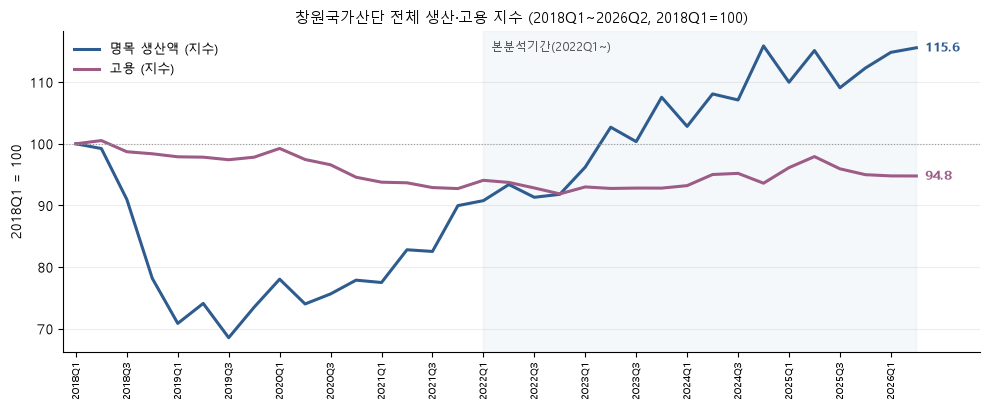

2026Q2 기준 지수: 생산 115.6 / 고용 94.8
주의: production_total은 명목 생산액이며 가격효과가 포함된다(Section 6 PPI 검증 참조).


In [8]:
t = total.sort_values('quarter').reset_index(drop=True)
t['production_idx'] = t.production_total / t.production_total.iloc[0] * 100
t['employment_idx'] = t.employment_total / t.employment_total.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(t.quarter, t.production_idx, color=SERIES_COLORS['production'], lw=2.2, label='명목 생산액 (지수)')
ax.plot(t.quarter, t.employment_idx, color=SERIES_COLORS['employment'], lw=2.2, label='고용 (지수)')

main_start_i = int(t.index[t.quarter == QUARTERS[0]][0])
ax.axvspan(main_start_i, len(t) - 1, color='#4C78A8', alpha=0.05, zorder=0)
ax.axhline(100, color='#999999', lw=0.8, ls=':')
ax.text(main_start_i + 0.3, 0.97, f'본분석기간({QUARTERS[0]}~)', fontsize=8.5, color='#555555',
        va='top', ha='left', transform=ax.get_xaxis_transform())

for col, key in [('production_idx', 'production'), ('employment_idx', 'employment')]:
    ax.annotate(f'{t[col].iloc[-1]:.1f}', (len(t) - 1, t[col].iloc[-1]), xytext=(6, 0),
                textcoords='offset points', va='center', fontsize=9,
                color=SERIES_COLORS[key], fontweight='bold')

ax.set_xticks(range(0, len(t), 2))
ax.set_xticklabels(t.quarter[::2], rotation=90, fontsize=7.5)
ax.set_ylabel(f'{t.quarter.iloc[0]} = 100')
ax.set_xlim(-0.5, len(t) + 1.5)
ax.set_title(f'창원국가산단 전체 생산·고용 지수 ({t.quarter.iloc[0]}~{t.quarter.iloc[-1]}, {t.quarter.iloc[0]}=100)',
             fontsize=11)
ax.legend(loc='upper left', frameon=False, fontsize=9)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'S1_배경_총량지수')
plt.show()

print(f'{t.quarter.iloc[-1]} 기준 지수: 생산 {t.production_idx.iloc[-1]:.1f} / 고용 {t.employment_idx.iloc[-1]:.1f}')
print('주의: production_total은 명목 생산액이며 가격효과가 포함된다(Section 6 PPI 검증 참조).')

In [9]:
_idx_gap = t.production_idx.iloc[-1] - t.employment_idx.iloc[-1]
print(f'{t.quarter.iloc[0]}=100 기준 {t.quarter.iloc[-1]} 지수: '
      f'명목 생산액 {t.production_idx.iloc[-1]:.1f}, 고용 {t.employment_idx.iloc[-1]:.1f}, '
      f'차이 {_idx_gap:+.1f}p')
print('총량 지수만으로는 업종별 방향과 변화 규모를 구분할 수 없다.')


2018Q1=100 기준 2026Q2 지수: 명목 생산액 115.6, 고용 94.8, 차이 +20.8p
총량 지수만으로는 업종별 방향과 변화 규모를 구분할 수 없다.


### 1-3. 업종별 규모 차이

업종은 생산·고용 규모가 서로 크게 다르다. 같은 변화율이라도 전체 인원에 미치는 크기가 다르므로 규모를 먼저 확인한다.

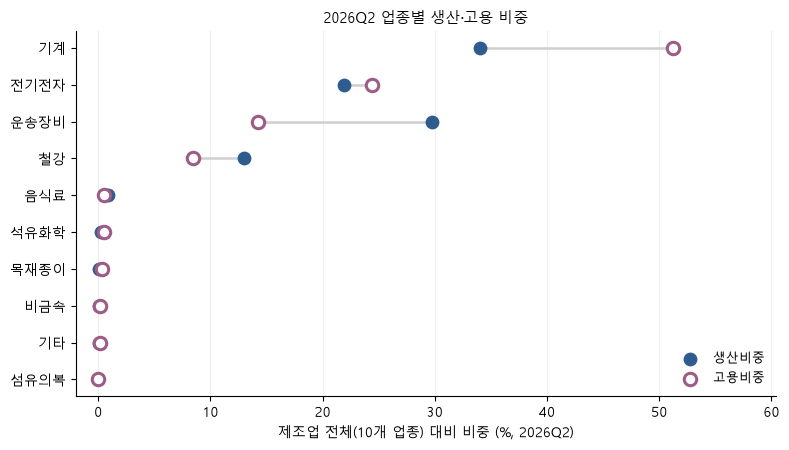

2026Q2 고용 상위 4개 업종: 기계, 전기전자, 운송장비, 철강
상위 4개 합계 비중: 명목 생산액 98.6%, 고용 98.2%


In [10]:
cur_lat = state[state.quarter == LATEST].set_index('industry')
share = pd.DataFrame({
    '생산비중': cur_lat.production / cur_lat.production.sum() * 100,
    '고용비중': cur_lat.employment / cur_lat.employment.sum() * 100,
}).reindex(IND_ORDER_EMP[::-1])

fig, ax = plt.subplots(figsize=(8, 4.6))
y = np.arange(len(share))
for yi, ind in zip(y, share.index):
    p, e = share.loc[ind, '생산비중'], share.loc[ind, '고용비중']
    ax.plot([p, e], [yi, yi], color='#CFCFCF', lw=1.8, zorder=1)
ax.scatter(share.생산비중, y, color=SERIES_COLORS['production'], s=80, zorder=2, label='생산비중')
ax.scatter(share.고용비중, y, s=80, zorder=2, label='고용비중',
           facecolor='white', edgecolor=SERIES_COLORS['employment'], linewidth=2.2)

ax.set_yticks(y)
ax.set_yticklabels(share.index, fontsize=10)
ax.set_xlabel(f'제조업 전체(10개 업종) 대비 비중 (%, {LATEST})')
ax.set_xlim(-2, max(share.max()) * 1.18)
ax.set_title(f'{LATEST} 업종별 생산·고용 비중', fontsize=11)
ax.legend(loc='lower right', frameon=False, fontsize=9)
style_ax(ax, ygrid=False, xgrid=True)
plt.tight_layout()
save_fig(fig, 'S1_배경_규모비중')
plt.show()

top4 = IND_ORDER_EMP[:4]
print(f'{LATEST} 고용 상위 {len(top4)}개 업종: {", ".join(top4)}')
print(f'상위 {len(top4)}개 합계 비중: 명목 생산액 {share.loc[top4, "생산비중"].sum():.1f}%, '
      f'고용 {share.loc[top4, "고용비중"].sum():.1f}%')

### 1-4. 10개 업종의 명목 생산액·고용 변화 경로

업종마다 단위와 규모가 다르므로 각 업종의 분석 시작분기 값을 100으로 두고 상대 경로를 비교한다. 지수는 EDA 전용 프레임에서만 계산하며 본분석 패널에는 저장하지 않는다.

패널별 y축 범위가 다르므로 업종 사이의 지수 높이를 직접 비교하지 않는다. 이 단계에서는 국면 색을 쓰지 않고 두 지표의 경로만 확인한다.


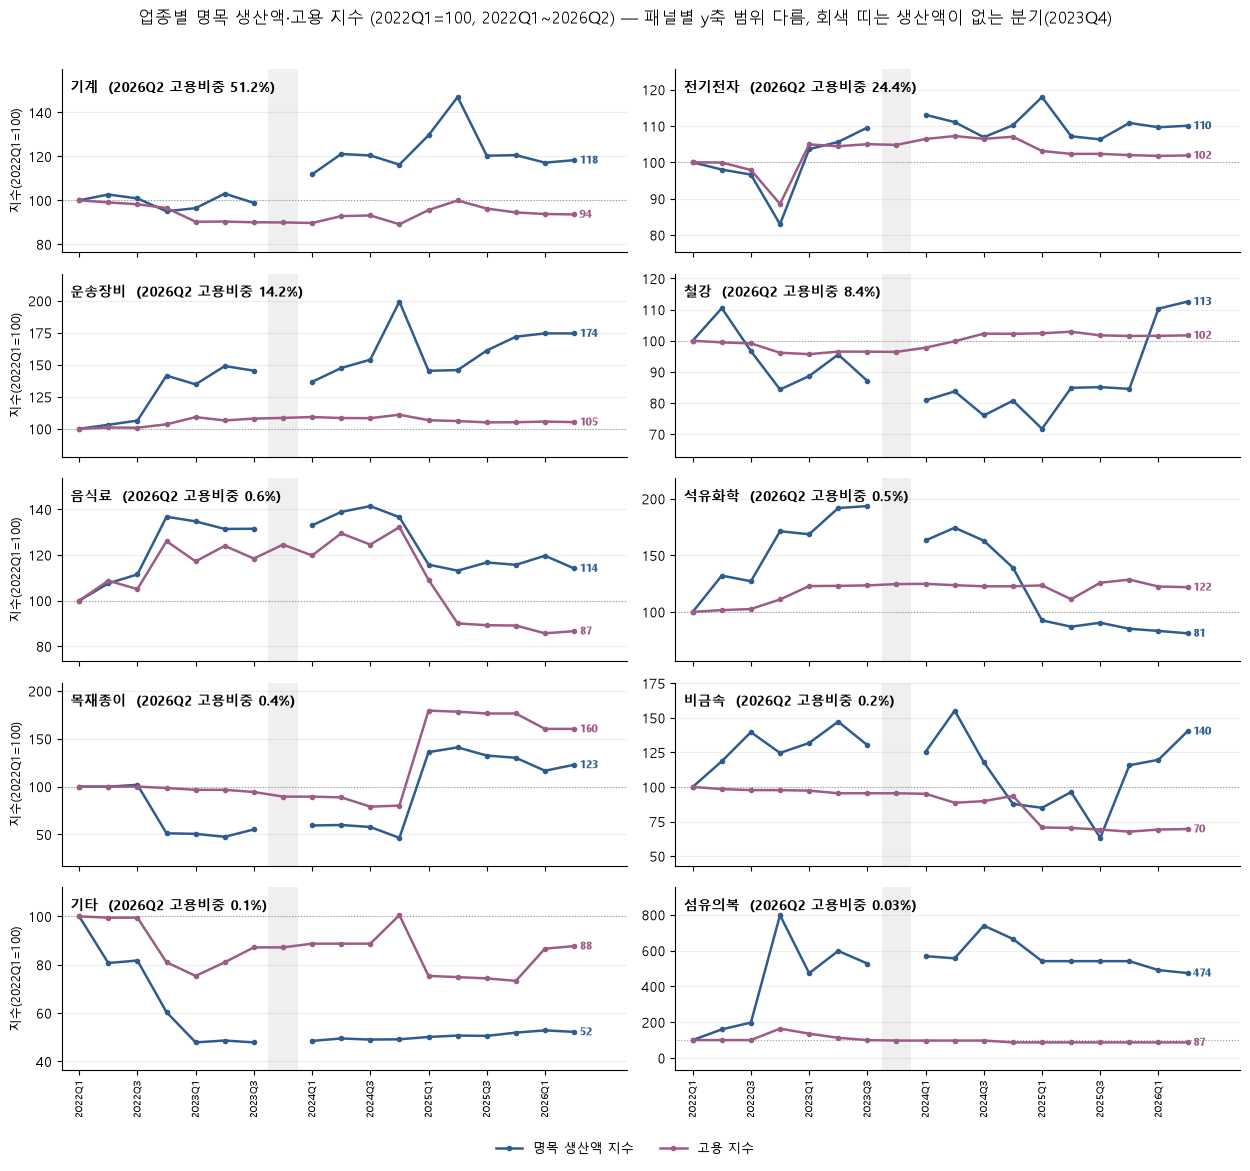

In [11]:
# ---- 1-4. 업종별 생산·고용 지수(각 업종의 분석 시작분기 = 100) -------------------
# state에 덮어쓰지 않는다. EDA 전용 임시 프레임에서만 지수를 만든다.
eda_idx = state[['industry', 'quarter', 'quarter_index', 'production', 'employment']].copy()
eda_base = (eda_idx[eda_idx.quarter == QUARTERS[0]].set_index('industry')[['production', 'employment']]
            .replace(0, np.nan))                      # 0으로 나누지 않는다
assert eda_base.notna().all().all(), f'{QUARTERS[0]} 기준값이 없는 업종이 있어 지수를 만들 수 없다'
eda_idx['production_index_industry'] = eda_idx.production / eda_idx.industry.map(eda_base.production) * 100
eda_idx['employment_index_industry'] = eda_idx.employment / eda_idx.industry.map(eda_base.employment) * 100

eda_qpos = {q: i for i, q in enumerate(QUARTERS)}
eda_missing_prod_q = sorted(state.loc[state.production.isna(), 'quarter'].unique())
EDA_NCOL = 2
eda_nrow = int(np.ceil(len(IND_ORDER_EMP) / EDA_NCOL))
fig, axes = plt.subplots(eda_nrow, EDA_NCOL, figsize=(12.6, 2.3 * eda_nrow), sharex=True)
for k, ind in enumerate(IND_ORDER_EMP):
    ax = axes[k // EDA_NCOL, k % EDA_NCOL]
    g = eda_idx[eda_idx.industry == ind].sort_values('quarter_index').reset_index(drop=True)
    xs = [eda_qpos[q] for q in g.quarter]
    ax.axhline(100, color='#999999', lw=0.8, ls=':', zorder=1)
    for q_na in eda_missing_prod_q:                   # 생산액이 없는 분기를 옅은 세로띠로 표시
        ax.axvspan(eda_qpos[q_na] - 0.5, eda_qpos[q_na] + 0.5, color='#EFEFEF', lw=0, zorder=0)
    for col, key, lab in [('production_index_industry', 'production', '명목 생산액 지수'),
                          ('employment_index_industry', 'employment', '고용 지수')]:
        ax.plot(xs, g[col], color=SERIES_COLORS[key], lw=1.8, marker='o', ms=3.0, label=lab, zorder=3)
        last = g[col].dropna()
        if len(last):
            ax.annotate(f'{last.iloc[-1]:.0f}', (xs[last.index[-1]], last.iloc[-1]),
                        xytext=(4, 0), textcoords='offset points', va='center',
                        fontsize=8.2, color=SERIES_COLORS[key], fontweight='bold')
    emp_sh = share.loc[ind, '고용비중']
    sh_txt = f'{emp_sh:.1f}%' if emp_sh >= 0.1 else f'{emp_sh:.2f}%'
    ax.text(0.015, 0.94, f'{ind}  ({LATEST} 고용비중 {sh_txt})', transform=ax.transAxes,
            va='top', ha='left', fontsize=10, fontweight='bold')
    ax.set_xlim(-0.6, len(QUARTERS) + 0.8)
    ax.margins(y=0.22)
    if k % EDA_NCOL == 0:
        ax.set_ylabel(f'지수({QUARTERS[0]}=100)', fontsize=8.8)
    style_ax(ax)
axes[0, 0].set_xticks(range(0, len(QUARTERS), 2))
axes[-1, 0].set_xticklabels(QUARTERS[::2], rotation=90, fontsize=7.4)
axes[-1, 1].set_xticklabels(QUARTERS[::2], rotation=90, fontsize=7.4)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.012),
           frameon=False, fontsize=9.5)                # 범례는 그림 전체에 한 번만
fig.suptitle(f'업종별 명목 생산액·고용 지수 ({QUARTERS[0]}=100, {QUARTERS[0]}~{LATEST}) — 패널별 y축 범위 다름, '
             f'회색 띠는 생산액이 없는 분기({", ".join(eda_missing_prod_q)})', fontsize=12, y=0.995)
fig.tight_layout(rect=[0, 0.018, 1, 0.985])
save_fig(fig, 'S1_EDA_업종별_생산고용지수')
plt.show()

eda_last_idx = (eda_idx[eda_idx.quarter == LATEST].set_index('industry')
                .reindex(IND_ORDER_EMP)[['production_index_industry', 'employment_index_industry']]
                .rename(columns={'production_index_industry': '생산지수',
                                 'employment_index_industry': '고용지수'}))
eda_last_idx['지수차(생산-고용)'] = eda_last_idx.생산지수 - eda_last_idx.고용지수
eda_pu = eda_last_idx[eda_last_idx.생산지수 > 100].index.tolist()
eda_eu = eda_last_idx[eda_last_idx.고용지수 > 100].index.tolist()
eda_split = eda_last_idx[((eda_last_idx.생산지수 > 100) & (eda_last_idx.고용지수 < 100)) |
                         ((eda_last_idx.생산지수 < 100) & (eda_last_idx.고용지수 > 100))].index.tolist()


In [12]:
print(f'{QUARTERS[0]}=100 기준 {LATEST}: 명목 생산액 지수 100 초과 {len(eda_pu)}개, '
      f'고용 지수 100 초과 {len(eda_eu)}개')
print(f'두 지수가 100의 반대편에 있는 업종 {len(eda_split)}개: '
      f'{", ".join(eda_split) if eda_split else "없음"}')
print(f'최신 지수 범위: 명목 생산액 {eda_last_idx.생산지수.min():.0f}~{eda_last_idx.생산지수.max():.0f}, '
      f'고용 {eda_last_idx.고용지수.min():.0f}~{eda_last_idx.고용지수.max():.0f}')
print('경로 차이의 원인은 현재 데이터로 확인할 수 없다.')


2022Q1=100 기준 2026Q2: 명목 생산액 지수 100 초과 8개, 고용 지수 100 초과 5개
두 지수가 100의 반대편에 있는 업종 5개: 기계, 음식료, 석유화학, 비금속, 섬유의복
최신 지수 범위: 명목 생산액 52~474, 고용 70~160
경로 차이의 원인은 현재 데이터로 확인할 수 없다.


### 1-5. 생산·고용 YoY 분포 및 극단 관측

경로 그림은 방향을 보여주지만 변화율의 크기가 업종별로 얼마나 다른지는 보여주지 않는다.
여기서는 **업종별 변화율의 범위**와 **절대 변화율이 큰 개별 관측**을 함께 확인한다.
생산 YoY와 고용 YoY 중 하나만 기준으로 뽑으면 다른 쪽 극단을 놓치므로 두 변수 각각에서 뽑아 합친다.

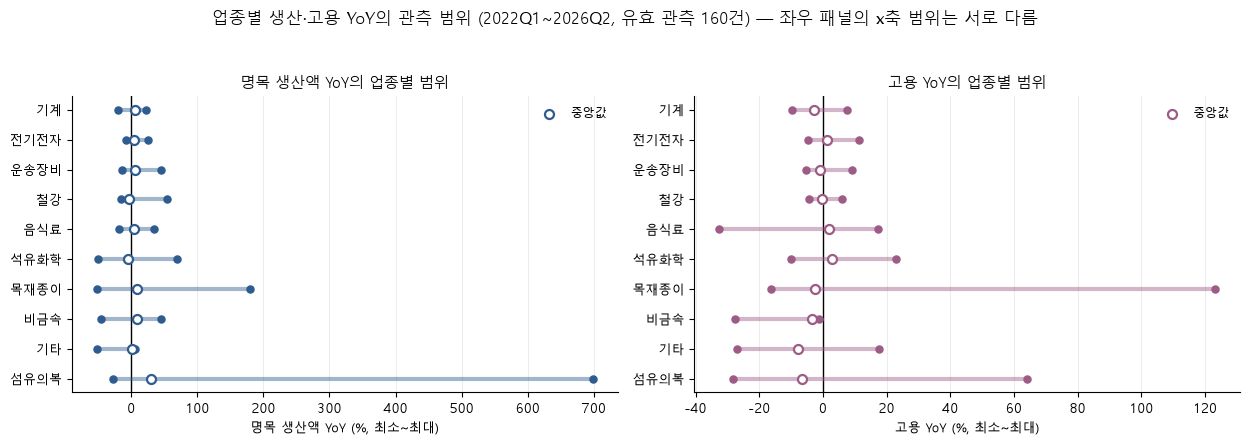

절대 변화율 상위 관측 (두 변수 각각 상위 8건을 합치고 중복 제거, 12건):


,,생산YoY%,고용YoY%,명목생산액(억원),고용(명),선정기준,해당분기_고용비중%
quarter,industry,,,,,,
2022Q4,섬유의복,698.2,64.1,12.0,64.0,생산·고용 모두,0.1
2023Q1,섬유의복,373.7,35.9,7.1,53.0,생산·고용 모두,0.0
2022Q3,섬유의복,296.0,-11.4,3.0,39.0,생산 YoY,0.0
2023Q2,섬유의복,274.0,12.8,9.0,44.0,생산 YoY,0.0
2022Q2,섬유의복,220.0,-11.4,2.4,39.0,생산 YoY,0.0
2025Q4,목재종이,180.2,120.1,175.7,471.0,생산·고용 모두,0.4
2023Q3,섬유의복,166.5,0.0,7.9,39.0,생산 YoY,0.0
2025Q2,목재종이,135.5,100.8,190.4,476.0,생산·고용 모두,0.4
2025Q3,목재종이,129.2,123.2,178.9,471.0,고용 YoY,0.4


과거 극단 관측의 고용비중은 각 관측 분기의 10개 업종 고용 합을 분모로 계산했다.


In [13]:
# ---- 1-5. 업종별 YoY 범위와 절대 변화율 상위 관측 ------------------------------
EDA_TOPN = 8                      # 두 변수 각각에서 뽑는 관측 수(중복 제거 후 합침)
eda_valid = state[state.valid_state == True].copy()

fig, axs = plt.subplots(1, 2, figsize=(12.6, 4.4))
eda_order = IND_ORDER_EMP[::-1]
yy = np.arange(len(eda_order))
for ax, col, key, lab in [(axs[0], 'production_yoy', 'production', '명목 생산액 YoY'),
                          (axs[1], 'employment_yoy', 'employment', '고용 YoY')]:
    stat = eda_valid.groupby('industry')[col].agg(['min', 'median', 'max']).reindex(eda_order)
    ax.axvline(0, color='black', lw=1.0, zorder=1)
    ax.hlines(yy, stat['min'], stat['max'], color=SERIES_COLORS[key], lw=3.0, alpha=0.45, zorder=2)
    ax.scatter(stat['min'], yy, color=SERIES_COLORS[key], s=26, zorder=3)
    ax.scatter(stat['max'], yy, color=SERIES_COLORS[key], s=26, zorder=3)
    ax.scatter(stat['median'], yy, facecolor='white', edgecolor=SERIES_COLORS[key],
               linewidth=1.6, s=42, zorder=4, label='중앙값')
    ax.set_yticks(yy)
    ax.set_yticklabels(stat.index, fontsize=9.5)
    ax.set_xlabel(f'{lab} (%, 최소~최대)', fontsize=9.5)
    ax.set_title(f'{lab}의 업종별 범위', fontsize=11)
    ax.legend(loc='upper right', frameon=False, fontsize=8.6)
    style_ax(ax, ygrid=False, xgrid=True)
fig.suptitle(f'업종별 생산·고용 YoY의 관측 범위 ({QUARTERS[0]}~{LATEST}, 유효 관측 {len(eda_valid)}건) — '
             f'좌우 패널의 x축 범위는 서로 다름', fontsize=12, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, 'S1_EDA_YoY분포_범위')
plt.show()

eda_range = pd.concat({
    '생산YoY%': eda_valid.groupby('industry').production_yoy.agg(['min', 'median', 'max']),
    '고용YoY%': eda_valid.groupby('industry').employment_yoy.agg(['min', 'median', 'max']),
}, axis=1).reindex(IND_ORDER_EMP)
# 두 변수 각각의 절대 변화율 상위 관측을 뽑아 합치고, 같은 업종×분기는 한 번만 남긴다.
eda_valid['abs_p'] = eda_valid.production_yoy.abs()
eda_valid['abs_e'] = eda_valid.employment_yoy.abs()
_pick = pd.concat([eda_valid.nlargest(EDA_TOPN, 'abs_p').assign(선정기준='생산 YoY'),
                   eda_valid.nlargest(EDA_TOPN, 'abs_e').assign(선정기준='고용 YoY')])
_basis = (_pick.groupby(['quarter', 'industry']).선정기준
          .agg(lambda s: '생산·고용 모두' if s.nunique() > 1 else s.iloc[0]))
eda_extreme = (_pick.drop_duplicates(['quarter', 'industry']).set_index(['quarter', 'industry'])
               .assign(선정기준=_basis))
eda_extreme = (eda_extreme.assign(_key=eda_extreme[['abs_p', 'abs_e']].max(axis=1))
               .sort_values('_key', ascending=False)
               [['production_yoy', 'employment_yoy', 'production', 'employment', '선정기준']]
               .rename(columns={'production_yoy': '생산YoY%', 'employment_yoy': '고용YoY%',
                                'production': '명목생산액(억원)', 'employment': '고용(명)'}))

# 과거 극단 관측의 규모는 최신분기가 아니라 해당 관측 분기의 제조업 고용 합을 분모로 계산한다.
_quarter_emp_total = state.groupby('quarter').employment.sum(min_count=len(INDUSTRIES))
eda_extreme['해당분기_고용비중%'] = [
    emp / _quarter_emp_total.loc[quarter] * 100
    for (quarter, _industry), emp in zip(eda_extreme.index, eda_extreme['고용(명)'])
]
print(f'절대 변화율 상위 관측 (두 변수 각각 상위 {EDA_TOPN}건을 합치고 중복 제거, {len(eda_extreme)}건):')
display(eda_extreme.round(1))

print('과거 극단 관측의 고용비중은 각 관측 분기의 10개 업종 고용 합을 분모로 계산했다.')

In [14]:
_p_span = eda_range[('생산YoY%', 'max')] - eda_range[('생산YoY%', 'min')]
_e_span = eda_range[('고용YoY%', 'max')] - eda_range[('고용YoY%', 'min')]
print(f'업종별 관측 범위 폭: 명목 생산액 YoY {_p_span.min():.0f}~{_p_span.max():.0f}%p, '
      f'고용 YoY {_e_span.min():.0f}~{_e_span.max():.0f}%p')
print(f'절대 변화율 상위 관측 {len(eda_extreme)}건은 '
      f'{eda_extreme.index.get_level_values("industry").nunique()}개 업종에서 관측됐다.')
print('변화율의 크기와 고용 인원 규모는 서로 다른 축이며, 극단값의 원인은 현재 데이터로 확인할 수 없다.')


업종별 관측 범위 폭: 명목 생산액 YoY 33~725%p, 고용 YoY 10~139%p
절대 변화율 상위 관측 12건은 3개 업종에서 관측됐다.
변화율의 크기와 고용 인원 규모는 서로 다른 축이며, 극단값의 원인은 현재 데이터로 확인할 수 없다.


### 1-6. 전체기간 생산–고용 관계

앞에서는 업종을 하나씩 따로 보았다. 여기서는 **전체 기간의 업종×분기 관측을 한 평면**에 놓고
생산 변화와 고용 변화가 항상 같은 방향으로 움직이는지 확인한다.

이 그림은 국면 분류의 *결과*가 아니라 국면을 도입하기 **전의 탐색**이다. 따라서
국면 이름(S1~S4)과 국면 색을 쓰지 않고 사분면에 미리 의미를 붙이지 않는다. 상관계수·회귀는 계산하지 않는다.

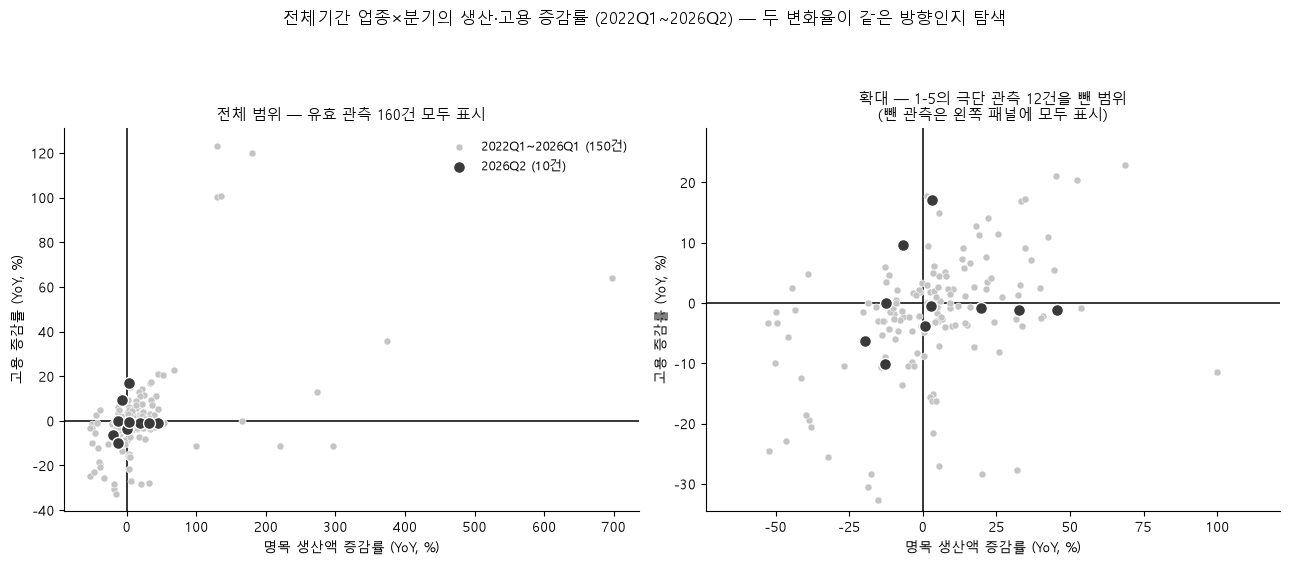

생산·고용 YoY를 모두 계산할 수 있는 업종×분기 관측 160건의 변화 방향:
          관측 수    비율%
방향                   
같은 방향    100.0   62.5
다른 방향     56.0   35.0
한 지표 0%    4.0    2.5
합계       160.0  100.0

한 지표가 정확히 0%인 관측 4건은 같은 방향/다른 방향 어디에도 넣지 않고 따로 센다.
0%를 뺀 156건 기준으로 보면 다른 방향은 35.9%다.
계산 불가(INVALID) 20건은 이 그림에서 제외했다.
2026Q2(짙은 점) 관측의 업종명은 붙이지 않았다. 최신분기의 업종별 위치는 Section 2에서 업종명과 함께 확인한다.


In [15]:
# ---- 1-6. 전체기간 업종×분기의 생산·고용 변화 방향 -----------------------------
# STATE_COLORS와 국면 이름을 쓰지 않는다. 여기서는 관측 분포만 본다.
eda_pair = state[state.valid_state == True].copy()
_p, _e = eda_pair.production_yoy, eda_pair.employment_yoy
eda_pair['방향'] = np.where((_p == 0) | (_e == 0), '한 지표 0%',
                          np.where(np.sign(_p) == np.sign(_e), '같은 방향', '다른 방향'))
EDA_DIRS = ['같은 방향', '다른 방향', '한 지표 0%']
eda_dir_counts = eda_pair.방향.value_counts().reindex(EDA_DIRS, fill_value=0)

# 확대 패널의 범위는 1-5에서 이미 확인한 극단 관측을 제외해서 정한다(새 기준을 만들지 않는다).
_ext_keys = set(eda_extreme.index)
eda_pair['극단'] = [(q, i) in _ext_keys for q, i in zip(eda_pair.quarter, eda_pair.industry)]
_core_mask = ~eda_pair.극단 | eda_pair.quarter.eq(LATEST)          # 최신분기는 항상 확대 범위에 포함
_core = eda_pair[_core_mask]
_n_out = int((~_core_mask).sum())
_xr = (_core.production_yoy.min(), _core.production_yoy.max())
_yr = (_core.employment_yoy.min(), _core.employment_yoy.max())
_xp, _yp = (_xr[1] - _xr[0]) * 0.14, (_yr[1] - _yr[0]) * 0.12

fig, axs = plt.subplots(1, 2, figsize=(13.0, 5.6))
for j, ax in enumerate(axs):
    zoom = (j == 1)
    past = eda_pair[eda_pair.quarter != LATEST]
    lat = eda_pair[eda_pair.quarter == LATEST]
    ax.axhline(0, color='black', lw=1.1, zorder=2)
    ax.axvline(0, color='black', lw=1.1, zorder=2)
    ax.scatter(past.production_yoy, past.employment_yoy, s=26, color='#C4C4C4',
               edgecolor='white', linewidth=0.4, zorder=3,
               label=f'{QUARTERS[0]}~{PREV} ({len(past)}건)')
    ax.scatter(lat.production_yoy, lat.employment_yoy, s=74, color='#3A3A3A',
               edgecolor='white', linewidth=1.0, zorder=4, label=f'{LATEST} ({len(lat)}건)')
    if zoom:
        ax.set_xlim(_xr[0] - _xp, _xr[1] + _xp)
        ax.set_ylim(_yr[0] - _yp, _yr[1] + _yp)
        # 최신분기 10개 업종이 좁은 구간에 모여 라벨이 겹치므로 업종명은 붙이지 않는다.
        # 최신분기의 업종별 위치는 Section 2 Q1-A에서 업종명과 함께 본다.
        ax.set_title(f'확대 — 1-5의 극단 관측 {_n_out}건을 뺀 범위\n(뺀 관측은 왼쪽 패널에 모두 표시)', fontsize=10.5)
    else:
        ax.set_title(f'전체 범위 — 유효 관측 {len(eda_pair)}건 모두 표시', fontsize=10.5)
        ax.legend(loc='upper right', frameon=False, fontsize=9)
    ax.set_xlabel('명목 생산액 증감률 (YoY, %)', fontsize=10)
    ax.set_ylabel('고용 증감률 (YoY, %)', fontsize=10)
    style_ax(ax, ygrid=False)
fig.suptitle(f'전체기간 업종×분기의 생산·고용 증감률 ({QUARTERS[0]}~{LATEST}) — '
             f'두 변화율이 같은 방향인지 탐색', fontsize=12.5, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, 'S1_EDA_전체기간_생산고용관계')
plt.show()

eda_dir_table = pd.DataFrame({
    '관측 수': eda_dir_counts,
    '비율%': eda_dir_counts / len(eda_pair) * 100,
})
eda_dir_table.loc['합계'] = [len(eda_pair), 100.0]
print(f'생산·고용 YoY를 모두 계산할 수 있는 업종×분기 관측 {len(eda_pair)}건의 변화 방향:')
print(eda_dir_table.round(1).to_string())
print()
print(f"한 지표가 정확히 0%인 관측 {int(eda_dir_counts['한 지표 0%'])}건은 같은 방향/다른 방향 어디에도 넣지 않고 따로 센다.")
print(f"0%를 뺀 {int(eda_dir_counts['같은 방향'] + eda_dir_counts['다른 방향'])}건 기준으로 보면 "
      f"다른 방향은 {eda_dir_counts['다른 방향'] / (eda_dir_counts['같은 방향'] + eda_dir_counts['다른 방향']) * 100:.1f}%다.")
print(f"계산 불가(INVALID) {int((~state.valid_state).sum())}건은 이 그림에서 제외했다.")
print(f'{LATEST}(짙은 점) 관측의 업종명은 붙이지 않았다. 최신분기의 업종별 위치는 Section 2에서 업종명과 함께 확인한다.')

results_summary['eda'] = {
    'n_valid_pairs': int(len(eda_pair)),
    'n_same_direction': int(eda_dir_counts['같은 방향']),
    'n_opposite_direction': int(eda_dir_counts['다른 방향']),
    'n_zero_involved': int(eda_dir_counts['한 지표 0%']),
    'opposite_pct_all': float(eda_dir_counts['다른 방향'] / len(eda_pair) * 100),
    'opposite_pct_excl_zero': float(eda_dir_counts['다른 방향'] /
                                    (eda_dir_counts['같은 방향'] + eda_dir_counts['다른 방향']) * 100),
    'n_invalid_excluded': int((~state.valid_state).sum()),
}

In [16]:
# EDA 결과를 Q1 → Q2 → Q3 질문으로 연결한다.
_tot = total.set_index(pd.PeriodIndex(total.quarter, freq='Q')).sort_index()
_tot = _tot.reindex(pd.period_range(_tot.index.min(), _tot.index.max(), freq='Q'))
_tot_yoy = pd.DataFrame({
    '명목 생산액': _tot.production_total.pct_change(4) * 100,
    '고용': _tot.employment_total.pct_change(4) * 100,
})
_tot_yoy = _tot_yoy.loc[[pd.Period(q, freq='Q') for q in QUARTERS]].dropna()
_tot_diff = _tot_yoy[(np.sign(_tot_yoy['명목 생산액']) != np.sign(_tot_yoy.고용)) &
                     (_tot_yoy['명목 생산액'] != 0) & (_tot_yoy.고용 != 0)]

_lat = state[(state.quarter == LATEST) & state.valid_state].set_index('industry')
_top_abs_emp_yoy = _lat.employment_yoy.abs().idxmax()
_top_emp = _lat.employment.idxmax()
e = results_summary['eda']
e.update({
    'total_quarters_compared': int(len(_tot_yoy)),
    'total_quarters_direction_differs': int(len(_tot_diff)),
    'latest_top_abs_employment_yoy_industry': _top_abs_emp_yoy,
    'latest_largest_employment_industry': _top_emp,
})

print('EDA 요약 — 상태 → 규모 → 시간')
print(f'Q1 근거: 유효 업종×분기 {e["n_valid_pairs"]}건 중 명목 생산액과 고용의 방향이 '
      f'달랐던 관측은 {e["n_opposite_direction"]}건({e["opposite_pct_all"]:.1f}%)이다.')
print(f'Q2 근거: {LATEST} 고용 변화율 절대값 최대 업종은 {_top_abs_emp_yoy}, '
      f'고용 인원 최대 업종은 {_top_emp}다.')
print('Q3 근거: 산점도는 시간 순서를 표시하지 않으므로 지속기간과 인접 전환을 별도로 확인한다.')
print('여기서 확인한 것은 분포·방향·규모의 관측 사실이며 원인이나 바람직함은 판단하지 않는다.')


EDA 요약 — 상태 → 규모 → 시간
Q1 근거: 유효 업종×분기 160건 중 명목 생산액과 고용의 방향이 달랐던 관측은 56건(35.0%)이다.
Q2 근거: 2026Q2 고용 변화율 절대값 최대 업종은 기타, 고용 인원 최대 업종은 기계다.
Q3 근거: 산점도는 시간 순서를 표시하지 않으므로 지속기간과 인접 전환을 별도로 확인한다.
여기서 확인한 것은 분포·방향·규모의 관측 사실이며 원인이나 바람직함은 판단하지 않는다.


## Section 2. Q1 상태 — 같은 고용 변화라도 명목 생산액 방향은 다른가?

고용 감소만으로 묶이는 업종에서도 명목 생산액은 증가하거나 감소할 수 있다.
두 지표의 전년동기 대비 방향을 결합해 S1~S4를 분류한다. 어느 한 지표가 0%이면 N, 계산할 수 없으면 INVALID다.
생산 증가가 실제 물량 증가라는 뜻은 아니다. 명목 생산액에는 가격 변화가 섞여 있으므로, 아래 최신분기 결과가 PPI 후보로 조정해도 유지되는지 Section 6에서 업종별로 비교하고, 명목·조정 두 값을 Section 7 진단카드와 Section 8 요약표에 함께 제시한다.

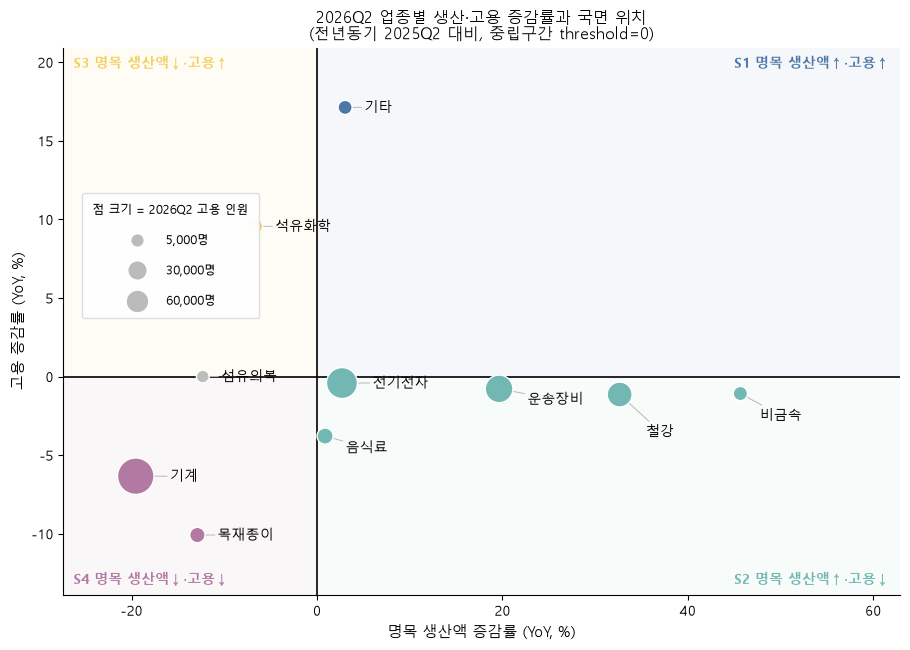

2026Q2 고용 감소 업종 7개 중 생산이 증가한 업종은 5개(전기전자, 운송장비, 철강, 음식료, 비금속)이며, 이들의 고용비중 합계는 47.7%였다.


In [17]:
# ---- Q1-A. 최신분기 업종별 국면 위치 -----------------------------------------
q = state[(state.quarter == LATEST) & state.valid_state].set_index('industry')
q = q.reindex([i for i in IND_ORDER_EMP if i in q.index])

fig, ax = plt.subplots(figsize=(9.2, 6.6))

xpad = (q.production_yoy.max() - q.production_yoy.min()) * 0.12
ypad = (q.employment_yoy.max() - q.employment_yoy.min()) * 0.14
xlim = (q.production_yoy.min() - xpad, q.production_yoy.max() + xpad * 2.2)
ylim = (q.employment_yoy.min() - ypad, q.employment_yoy.max() + ypad)
ax.set_xlim(xlim); ax.set_ylim(ylim)

# 사분면 배경 — 아주 옅게. 코너 라벨이 국면 의미를 직접 말한다.
for (sx, sy), s in [((1, 1), 'S1'), ((1, -1), 'S2'), ((-1, 1), 'S3'), ((-1, -1), 'S4')]:
    x0 = 0 if sx > 0 else xlim[0]
    y0 = 0 if sy > 0 else ylim[0]
    ax.add_patch(Rectangle((x0, y0), (xlim[1] if sx > 0 else 0) - x0,
                           (ylim[1] if sy > 0 else 0) - y0,
                           color=STATE_COLORS[s], alpha=0.055, lw=0, zorder=0))
    ax.text(xlim[1] - (xlim[1] - xlim[0]) * 0.012 if sx > 0 else xlim[0] + (xlim[1] - xlim[0]) * 0.012,
            ylim[1] - (ylim[1] - ylim[0]) * 0.015 if sy > 0 else ylim[0] + (ylim[1] - ylim[0]) * 0.015,
            STATE_LABELS[s], ha='right' if sx > 0 else 'left', va='top' if sy > 0 else 'bottom',
            fontsize=10, color=STATE_COLORS[s], fontweight='bold', zorder=1)

ax.axhline(0, color='black', lw=1.2, zorder=2)
ax.axvline(0, color='black', lw=1.2, zorder=2)

emp_max = q.employment.max()
sizes = 70 + 620 * np.sqrt(q.employment / emp_max)
ax.scatter(q.production_yoy, q.employment_yoy, s=sizes,
           color=[STATE_COLORS[s] for s in q.state],
           edgecolor='white', linewidth=1.0, zorder=4)

radii = (np.sqrt(sizes / np.pi) + 6) * 1.4   # points -> 화면 px 환산
# 라벨은 업종명만 — 고용 인원은 점 크기와 범례가 이미 전달한다(라벨을 길게 하면 서로 겹친다).
place_labels(ax, q.production_yoy.values, q.employment_yoy.values, list(q.index),
             offsets=radii, fontsize=10.2, min_gap_px=15, split_at=0)

# 점 크기 범례 — 텍스트 설명 대신 실제 원으로 보여준다.
leg_vals = [5_000, 30_000, 60_000]
handles = [Line2D([], [], marker='o', ls='', markerfacecolor='#BBBBBB', markeredgecolor='white',
                  markersize=np.sqrt(70 + 620 * np.sqrt(v / emp_max)) * 0.62,
                  label=f'{v:,}명') for v in leg_vals]
# 사분면 코너 라벨과 겹치지 않도록 좌측 여백(관측치가 없는 영역)에 둔다.
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(0.015, 0.62),
          frameon=True, framealpha=0.95, edgecolor='#DDDDDD',
          fontsize=8.6, title=f'점 크기 = {LATEST} 고용 인원', title_fontsize=8.6,
          labelspacing=1.5, borderpad=0.9, handletextpad=1.4)

ax.set_xlabel('명목 생산액 증감률 (YoY, %)', fontsize=10.5)
ax.set_ylabel('고용 증감률 (YoY, %)', fontsize=10.5)
ax.set_title(f'{LATEST} 업종별 생산·고용 증감률과 국면 위치\n'
             f'(전년동기 {BASE_Q} 대비, 중립구간 threshold={THRESHOLD})', fontsize=11.5)
style_ax(ax, ygrid=False)
plt.tight_layout()
save_fig(fig, 'Q1A_최신분기_사분면')
plt.show()

d = state[state.quarter == LATEST].set_index('industry').reindex(IND_ORDER_EMP)
dn = d[(d.employment_yoy < 0) & d.valid_state]
up = dn[dn.production_yoy > 0]
results_summary['q1_latest'] = {'quarter': LATEST, 'n_down': len(dn), 'n_nominal_up': len(up),
    'nominal_up_industries': list(up.index), 'employment_denominator': float(d.employment.sum()),
    'nominal_employment_numerator': float(up.employment.sum()),
    'nominal_employment_share_pct': float(up.employment.sum()/d.employment.sum()*100)}

print(f'{LATEST} 고용 감소 업종 {len(dn)}개 중 생산이 증가한 업종은 {len(up)}개'
      f'({", ".join(up.index)})이며, 이들의 고용비중 합계는 '
      f'{results_summary["q1_latest"]["nominal_employment_share_pct"]:.1f}%였다.')


In [18]:
r = results_summary['q1_latest']
print(f'{LATEST} 고용 감소 업종 {r["n_down"]}개 중 명목 생산액 증가 업종은 '
      f'{r["n_nominal_up"]}개({", ".join(r["nominal_up_industries"])})다.')
print(f'해당 업종의 고용 합은 제조업 전체 {r["employment_denominator"]:,.0f}명의 '
      f'{r["nominal_employment_share_pct"]:.1f}%다.')
print('같은 고용 감소에서도 명목 생산액 방향이 다르다는 관측이며 원인은 확인할 수 없다.')
print('※ 명목 생산액 기준 수치다. PPI 후보로 조정한 값과의 비교는 Section 6 표와 Section 8 요약에 함께 제시한다.')


2026Q2 고용 감소 업종 7개 중 명목 생산액 증가 업종은 5개(전기전자, 운송장비, 철강, 음식료, 비금속)다.
해당 업종의 고용 합은 제조업 전체 114,830명의 47.7%다.
같은 고용 감소에서도 명목 생산액 방향이 다르다는 관측이며 원인은 확인할 수 없다.
※ 명목 생산액 기준 수치다. PPI 후보로 조정한 값과의 비교는 Section 6 표와 Section 8 요약에 함께 제시한다.


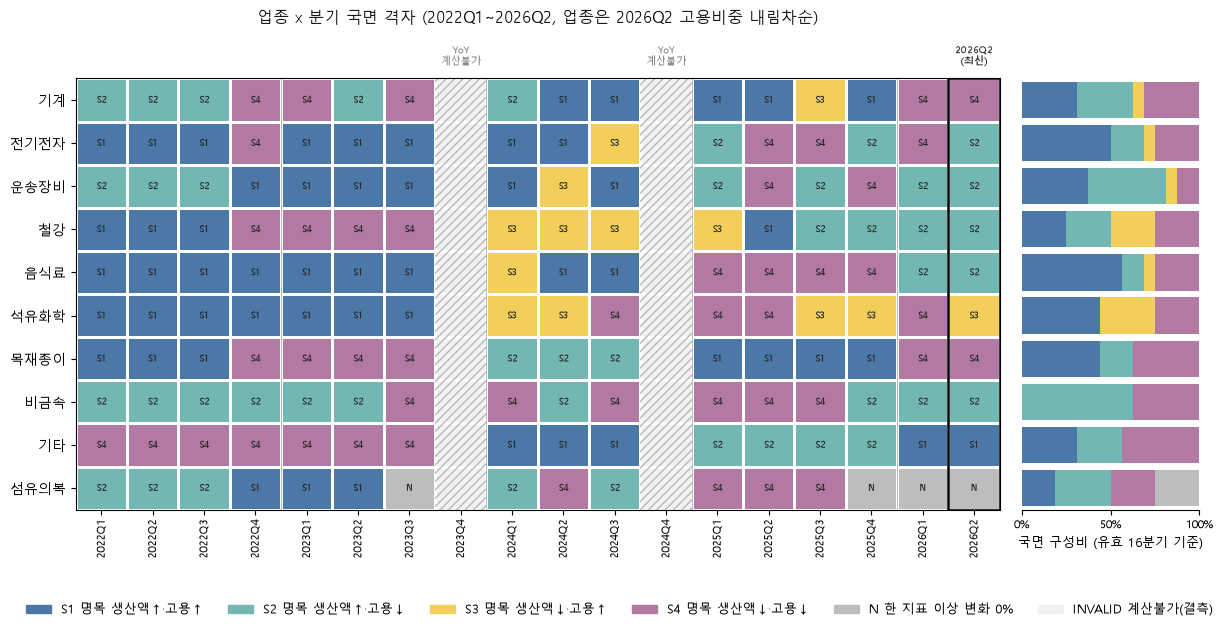

In [19]:
# ---- Q1-B. 관측기간 업종x분기 국면 분포 --------------------------------------
pivot = state.pivot(index='industry', columns='quarter', values='state').reindex(
    index=IND_ORDER_EMP, columns=QUARTERS)
code_map = {s: i for i, s in enumerate(STATES6)}
code_arr = pivot.apply(lambda col: col.map(code_map)).astype(float).values
n_ind, n_q = code_arr.shape

fig = plt.figure(figsize=(14.5, 5.6))
gs = fig.add_gridspec(1, 2, width_ratios=[5.2, 1], wspace=0.04)
ax = fig.add_subplot(gs[0])
axr = fig.add_subplot(gs[1], sharey=ax)

cmap = ListedColormap([STATE_COLORS[s] for s in STATES6])
norm = BoundaryNorm(np.arange(-0.5, len(STATES6) + 0.5, 1), cmap.N)
ax.pcolormesh(code_arr, cmap=cmap, norm=norm, edgecolors='white', linewidth=0.8)

ax.set_xticks(np.arange(n_q) + 0.5)
ax.set_xticklabels(QUARTERS, rotation=90, fontsize=8)
ax.set_yticks(np.arange(n_ind) + 0.5)
ax.set_yticklabels(IND_ORDER_EMP, fontsize=10)
ax.set_ylim(0, n_ind)
ax.invert_yaxis()

for ri in range(n_ind):
    for qi in range(n_q):
        label = pivot.iloc[ri, qi]
        if label != 'INVALID':
            ax.text(qi+.5, ri+.5, label, ha='center', va='center', fontsize=6.7, color='#222222')

for q_inv in INVALID_QUARTERS:
    qi = QUARTERS.index(q_inv)
    for ri in range(n_ind):
        ax.add_patch(Rectangle((qi, ri), 1, 1, fill=False, hatch='////',
                               edgecolor='#B8B8B8', linewidth=0))
    ax.text(qi + 0.5, -0.28, 'YoY\n계산불가', ha='center', va='bottom', fontsize=7, color='#888888')

for i, qq in enumerate(QUARTERS):
    if qq.endswith('Q1'):
        ax.axvline(i, color='#AAAAAA', lw=0.7, alpha=0.8)
ax.add_patch(Rectangle((n_q - 1, 0), 1, n_ind, fill=False, edgecolor='black', linewidth=1.8))
ax.text(n_q - 0.5, -0.28, f'{LATEST}\n(최신)', ha='center', va='bottom', fontsize=7.5,
        color='#333333', fontweight='bold')

# 우측: 업종별 국면 구성비. INVALID는 두 분기 모두 전 업종 공통이라 정보가 없어 제외하고,
# 유효 분기(16분기) 기준으로 정규화한다. y좌표는 히트맵 셀 중심(+0.5)에 맞춘다.
valid = state[state.state != 'INVALID']
comp = (pd.crosstab(valid.industry, valid.state, normalize='index')
        .reindex(index=IND_ORDER_EMP).reindex(columns=STATES5, fill_value=0))
yb = np.arange(n_ind) + 0.5
left = np.zeros(n_ind)
for col in STATES5:
    axr.barh(yb, comp[col].values, left=left, color=STATE_COLORS[col], height=0.84)
    left += comp[col].values
axr.set_xlim(0, 1)
axr.set_xticks([0, 0.5, 1]); axr.set_xticklabels(['0%', '50%', '100%'], fontsize=8)
axr.set_xlabel(f'국면 구성비 (유효 {len(QUARTERS) - len(INVALID_QUARTERS)}분기 기준)', fontsize=9)
plt.setp(axr.get_yticklabels(), visible=False)
axr.tick_params(axis='y', length=0)
axr.spines['top'].set_visible(False); axr.spines['right'].set_visible(False)
axr.spines['left'].set_visible(False)

handles = [Rectangle((0, 0), 1, 1, color=STATE_COLORS[k]) for k in STATES6]
fig.legend(handles, [STATE_LABELS[k] for k in STATES6], loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.10), frameon=False, fontsize=9)
ax.set_title(f'업종 x 분기 국면 격자 ({QUARTERS[0]}~{LATEST}, 업종은 {LATEST} 고용비중 내림차순)',
             fontsize=11.5, pad=40)
plt.tight_layout()
save_fig(fig, 'Q1B_국면격자')
plt.show()

In [20]:
emp_down = state[(state.employment_yoy < 0) & state.valid_state]
simple_pct = (emp_down.production_yoy > 0).mean()
weighted_pct = ((emp_down.production_yoy > 0) * emp_down.employment).sum() / emp_down.employment.sum()
t4 = emp_down[emp_down.industry.isin(IND_ORDER_EMP[:4])]
results_summary['q1_history'] = {
    'n_down': len(emp_down),
    'n_up_down': int((emp_down.production_yoy > 0).sum()),
    'simple_pct': float(simple_pct * 100),
    'weighted_pct': float(weighted_pct * 100),
}
print(f'전체 관측기간 고용 감소 {len(emp_down)}건 중 명목 생산액 증가 '
      f'{int((emp_down.production_yoy > 0).sum())}건({simple_pct:.1%})')
print(f'업종×분기 고용 인원 가중 비율 {weighted_pct:.1%}; 고용 상위 4개 업종 관측 비율 '
      f'{(t4.production_yoy > 0).mean():.1%} (n={len(t4)})')
print('관측 건수 비율과 고용 인원 가중 비율은 의미가 다르며, 반복 관측을 독립 표본으로 보지 않는다.')


전체 관측기간 고용 감소 89건 중 명목 생산액 증가 43건(48.3%)
업종×분기 고용 인원 가중 비율 53.0%; 고용 상위 4개 업종 관측 비율 55.9% (n=34)
관측 건수 비율과 고용 인원 가중 비율은 의미가 다르며, 반복 관측을 독립 표본으로 보지 않는다.


참고: ±0.5/1/2% 민감도는 본분석(threshold=0)을 대체하지 않으며, 국면 경계 부근 관측치가 얼마나
민감한지만 확인한다.

In [21]:
# 중립구간만 변경한 보조집계. 본분석 국면은 유지한다.
sensitivity_rows = []
for threshold in [0.5, 1.0, 2.0]:
    values = [classify(r.production_yoy, r.employment_yoy, threshold) for r in state.itertuples()]
    counts = pd.Series(values).value_counts().reindex(STATES6, fill_value=0)
    sensitivity_rows.append({'threshold': threshold, **counts.to_dict()})
sens_summary = pd.DataFrame(sensitivity_rows).set_index('threshold')
display(sens_summary)
print('같은 패널에서 중립구간만 변경한 보조 집계다. 기존 민감도 CSV와의 대조 검증은 하지 않았다.')

,S1,S2,S3,S4,N,INVALID
threshold,,,,,,
0.5,51,41,11,46,11,20
1.0,50,33,11,43,23,20
2.0,41,29,7,36,47,20


같은 패널에서 중립구간만 변경한 보조 집계다. 기존 민감도 CSV와의 대조 검증은 하지 않았다.


## Section 3. Q2 규모 — 제조업 전체 고용 증감에서 어떤 업종의 변화가 큰가?

국면은 방향을 보여주지만 인원 변화의 크기는 알려주지 않는다. 업종별 고용 증감 인원과 고용비중을 함께 확인한다.
고용 규모와 변화 규모를 기준으로 상세 경로를 표시할 업종을 정한다. 모든 업종은 전체 표와 지속·전환 집계에 포함한다.

기여율은 업종별 증감을 제조업 전체 순증감으로 나눈 값이다.
순증감이 작아 비율이 과도해지는 경우에는 증감 인원을 중심으로 제시하며, 표시 기준은 Section 0의 설정을 따른다.

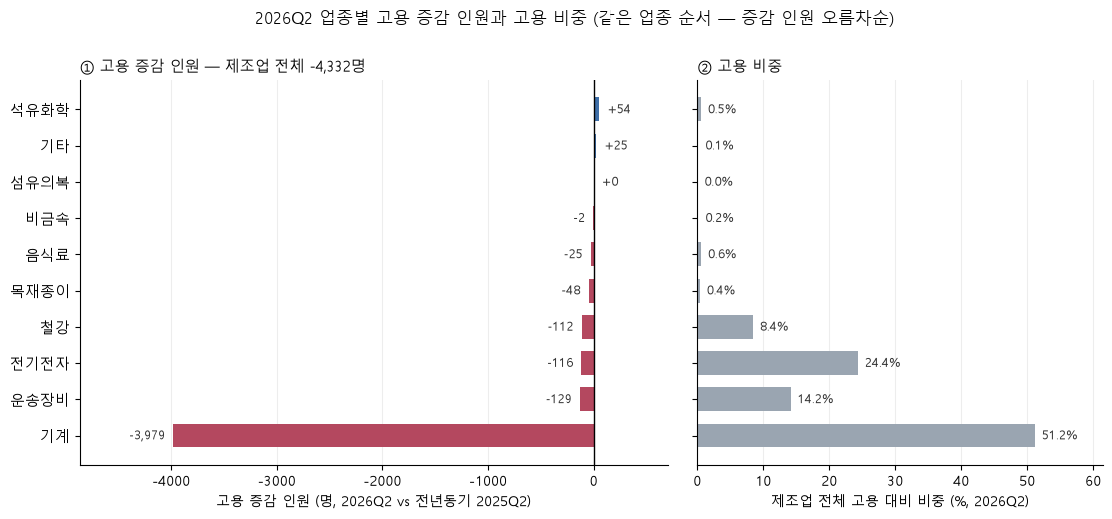

2026Q2 제조업 전체(10개 업종) 고용 114,830명, 전년동기 대비 -4,332명 (-3.64%)
업종별 증감 절대합 4,490명 / 순변화/총변화 비율 0.965 -> 기여율 사용 가능


In [22]:
# ---- Q2-A. 최신분기 고용 증감 인원 | 고용 비중 --------------------------------
d = state[state.quarter == LATEST].set_index('industry')
q2 = pd.DataFrame({
    '고용': d.employment,
    '고용_전년': d.employment_lag4_lvl,
    '증감인원': d.emp_delta,
    '증감률%': d.employment_yoy,
    '고용비중%': d.employment / d.employment.sum() * 100,
    '국면': d.state,
}).sort_values('증감인원')
net = q2.증감인원.sum()
ratio = mfg.loc[LATEST, 'net_gross_ratio']
usable = bool(mfg.loc[LATEST, 'contrib_usable'])
if usable:
    q2['기여율%'] = q2.증감인원 / net * 100

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), sharey=True,
                         gridspec_kw={'width_ratios': [1.45, 1], 'wspace': 0.06})
y = np.arange(len(q2))

ax = axes[0]
ax.barh(y, q2.증감인원, height=0.66,
        color=[DELTA_COLORS['down'] if v < 0 else (DELTA_COLORS['up'] if v > 0 else DELTA_COLORS['neutral'])
               for v in q2.증감인원])
ax.axvline(0, color='black', lw=1.0)
bar_labels(ax, y, q2.증감인원.values, fmt=lambda v: f'{v:+,.0f}', fontsize=9.2)
ax.set_yticks(y); ax.set_yticklabels(q2.index, fontsize=10.5)
ax.set_xlabel(f'고용 증감 인원 (명, {LATEST} vs 전년동기 {BASE_Q})', fontsize=10.2)
_span = q2.증감인원.max() - q2.증감인원.min()
ax.set_xlim(q2.증감인원.min() - _span * 0.22, max(q2.증감인원.max(), 0) + _span * 0.16)
ax.set_title(f'① 고용 증감 인원 — 제조업 전체 {net:+,.0f}명', fontsize=11, loc='left')
style_ax(ax, ygrid=False, xgrid=True)

ax = axes[1]
ax.barh(y, q2['고용비중%'], height=0.66, color='#9AA5B1')
bar_labels(ax, y, q2['고용비중%'].values, fmt=lambda v: f'{v:.1f}%', fontsize=9.2)
ax.set_xlabel(f'제조업 전체 고용 대비 비중 (%, {LATEST})', fontsize=10.2)
ax.set_xlim(0, max(q2['고용비중%'].max()*1.2, 1))
ax.set_title('② 고용 비중', fontsize=11, loc='left')
style_ax(ax, ygrid=False, xgrid=True)

fig.suptitle(f'{LATEST} 업종별 고용 증감 인원과 고용 비중 (같은 업종 순서 — 증감 인원 오름차순)',
             fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'Q2A_고용증감_비중')
plt.show()

print(f'{LATEST} 제조업 전체(10개 업종) 고용 {q2.고용.sum():,.0f}명, '
      f'전년동기 대비 {net:+,.0f}명 ({net / q2.고용_전년.sum() * 100:+.2f}%)')
print(f'업종별 증감 절대합 {q2.증감인원.abs().sum():,.0f}명 / 순변화/총변화 비율 {ratio:.3f}'
      f' -> 기여율 사용 {"가능" if usable else "불가"}')


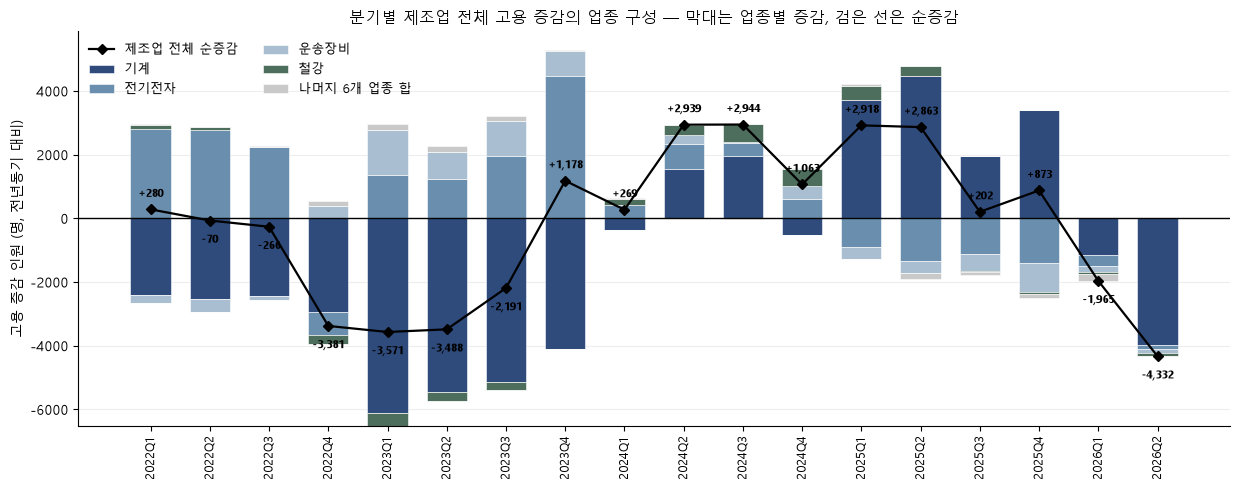

막대는 주요 업종과 나머지 업종의 순증감 합이다. 나머지 그룹 내부의 상쇄는 그림에 드러나지 않는다. 총변화는 아래 표의 업종별 증감 절대합을 따른다.


In [23]:
# ---- Q2-B. 분기별 제조업 전체 고용 변화의 업종 구성 ---------------------------
MAIN_CAND = IND_ORDER_EMP[:4]
REST = [i for i in IND_ORDER_EMP if i not in MAIN_CAND]

dd = state.dropna(subset=['emp_delta'])
qs = [q for q in QUARTERS if q in set(dd.quarter)]
piv = dd.pivot_table(index='quarter', columns='industry', values='emp_delta').reindex(qs)
plot_df = piv[MAIN_CAND].copy()
plot_df[f'나머지 {len(REST)}개 업종 합'] = piv[REST].sum(axis=1)
cols = list(plot_df.columns)
colors = MAIN_COLORS + [REST_COLOR]

fig, ax = plt.subplots(figsize=(12.5, 5.0))
x = np.arange(len(qs))
pos = np.zeros(len(qs)); neg = np.zeros(len(qs))
for col, c in zip(cols, colors):
    v = plot_df[col].fillna(0).values
    vp = np.where(v > 0, v, 0); vn = np.where(v < 0, v, 0)
    ax.bar(x, vp, bottom=pos, color=c, width=0.68, label=col, edgecolor='white', linewidth=0.4)
    ax.bar(x, vn, bottom=neg, color=c, width=0.68, edgecolor='white', linewidth=0.4)
    pos += vp; neg += vn

netv = plot_df.sum(axis=1).values
ax.plot(x, netv, color='black', lw=1.6, marker='D', ms=5, zorder=5, label='제조업 전체 순증감')
for xi, v in zip(x, netv):
    ax.annotate(f'{v:+,.0f}', (xi, v), xytext=(0, 9 if v >= 0 else -16), textcoords='offset points',
                ha='center', fontsize=7.8, color='black', fontweight='bold')

ax.axhline(0, color='black', lw=1.0)
ax.set_xticks(x); ax.set_xticklabels(qs, rotation=90, fontsize=8.5)
ax.set_ylabel('고용 증감 인원 (명, 전년동기 대비)', fontsize=10.2)
ax.set_title('분기별 제조업 전체 고용 증감의 업종 구성 — 막대는 업종별 증감, 검은 선은 순증감',
             fontsize=11.5)
ax.legend(loc='upper left', frameon=False, fontsize=9, ncol=2)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'Q2B_분기별_고용변화구성')
plt.show()

print('막대는 주요 업종과 나머지 업종의 순증감 합이다. 나머지 그룹 내부의 상쇄는 그림에 드러나지 않는다. 총변화는 아래 표의 업종별 증감 절대합을 따른다.')


In [24]:
RECENT4 = QUARTERS[-4:]
rec_state = state[state.quarter.isin(RECENT4)]
rec = rec_state.groupby('industry').emp_delta.agg(
    최근4분기_평균고용_전년대비증감=lambda s: s.sum(min_count=len(RECENT4)) / len(RECENT4),
    최근4분기_YoY증감절대합=lambda s: s.abs().sum())
# 네 분기 YoY 증감의 합을 분기 수로 나누면 '최근 4분기 평균 고용 - 그 이전 4분기 평균 고용'과 같다.
# 기간 순증감(최신분기 - 4분기 전)과는 다른 값이다. 절대합은 상세표시 대상을 고르는 변화 크기 지표일 뿐이다.
rec['최근4분기_기간순증감'] = q2.증감인원
summary = pd.DataFrame({'고용비중%': q2['고용비중%'], f'{LATEST}_증감인원':q2.증감인원,
    f'{LATEST}_증감률%':q2['증감률%'], f'{LATEST}_국면':q2.국면}).join(rec).reindex(IND_ORDER_EMP)
SHARE_CUT = 5.0
ABS_CUT = 300
c1 = summary['고용비중%'] >= SHARE_CUT
c2 = summary['최근4분기_YoY증감절대합'] >= ABS_CUT
MAIN_IND = [i for i in IND_ORDER_EMP if c1[i] and c2[i]]
summary['상세표시대상'] = c1 & c2
# 규모를 통제한 비교 — 비례배분 기준선.
# 기준선 = 기준분기(전년동기) 고용비중 x 제조업 전체 순증감. 당분기 비중을 쓰면 결과가 분모에 다시 들어간다.
q2['비례기대증감'] = q2.고용_전년 / q2.고용_전년.sum() * net
q2['초과증감'] = q2.증감인원 - q2.비례기대증감
summary = summary.join(q2[['비례기대증감', '초과증감']])
results_summary['q2'] = {'quarter': LATEST, 'employment':float(q2.고용.sum()), 'net_delta':float(net),
    'net_yoy_pct':float(net/q2.고용_전년.sum()*100), 'ratio':float(ratio), 'contrib_usable':usable,
    'largest_decrease_industries':q2.index[q2.증감인원.eq(q2.증감인원.min()) & q2.증감인원.lt(0)].tolist(),
    'min_delta':float(q2.증감인원.min()), 'main_industries':MAIN_IND,
    'main_share_pct':float(summary.loc[MAIN_IND,'고용비중%'].sum()),
    'selection_share_cut':SHARE_CUT,'selection_abs_cut':ABS_CUT,
    'baseline_max_excess_decrease_industry': q2.초과증감.idxmin(),
    'baseline_max_excess_decrease': float(q2.초과증감.min()),
    'baseline_excess': {i: float(q2.loc[i, '초과증감']) for i in IND_ORDER_EMP}}
print(f'상세표시 기준: 고용비중 {SHARE_CUT:g}% 이상, 최근 {len(RECENT4)}분기 YoY 증감 절대합 {ABS_CUT:,}명 이상.')
print('기존 표시 기준을 유지한 것이며, 정책 우선순위 또는 통계적으로 검증된 경계가 아니다. 모든 업종은 전체 표에 남긴다.')
print(f'최근4분기_평균고용_전년대비증감 = 최근 {len(RECENT4)}분기 평균 고용 - 그 이전 {len(RECENT4)}분기 평균 고용. 최신분기의 기간 순증감과 다른 값이다.')
print('YoY 증감절대합은 같은 인원이 여러 분기에 반복 반영될 수 있어 신규·소멸 일자리 수로 해석하지 않으며, 상세표시 대상 선정에만 쓴다.')
summary.to_csv(DIR_TAB/'Q2_규모요약.csv', encoding='utf-8-sig')

상세표시 기준: 고용비중 5% 이상, 최근 4분기 YoY 증감 절대합 300명 이상.
기존 표시 기준을 유지한 것이며, 정책 우선순위 또는 통계적으로 검증된 경계가 아니다. 모든 업종은 전체 표에 남긴다.
최근4분기_평균고용_전년대비증감 = 최근 4분기 평균 고용 - 그 이전 4분기 평균 고용. 최신분기의 기간 순증감과 다른 값이다.
YoY 증감절대합은 같은 인원이 여러 분기에 반복 반영될 수 있어 신규·소멸 일자리 수로 해석하지 않으며, 상세표시 대상 선정에만 쓴다.


In [25]:
r = results_summary['q2']
change_word = '감소' if r['net_delta'] < 0 else ('증가' if r['net_delta'] > 0 else '변화 없음')
smallest_text = ', '.join(r['largest_decrease_industries']) or '해당 없음'
print(f'{LATEST} 제조업 고용 {r["employment"]:,.0f}명, 전년동기 대비 '
      f'{r["net_delta"]:+,.0f}명({r["net_yoy_pct"]:+.1f}%)')
print(f'감소 인원이 가장 큰 업종: {smallest_text}; 상세 경로 표시 업종: '
      f'{", ".join(MAIN_IND) if MAIN_IND else "없음"}')
print('최근 4분기 평균 고용의 전년 대비 증감과 YoY 증감절대합은 기간 순증감이나 기업별 채용·퇴사 인원이 아니다.')


2026Q2 제조업 고용 114,830명, 전년동기 대비 -4,332명(-3.6%)
감소 인원이 가장 큰 업종: 기계; 상세 경로 표시 업종: 기계, 전기전자, 운송장비, 철강
최근 4분기 평균 고용의 전년 대비 증감과 YoY 증감절대합은 기간 순증감이나 기업별 채용·퇴사 인원이 아니다.


### Q2-C. 규모를 통제한 비교 — 비례배분 기준선

업종이 크면 증감 인원도 크게 나타난다. 크기 효과를 걷어내기 위해, 제조업 전체 순증감을 **전년동기 고용비중대로 나눈 값**을 기준선으로 둔다.

- 기준선(비례기대증감) = 전년동기 고용비중 × 제조업 전체 순증감
- 초과증감 = 실제 증감 − 기준선

기준선은 "모든 업종이 제조업 전체와 같은 비율로 변했다면"이라는 가정의 비교값이다. 초과증감의 원인(채용·감원·업종 구성 차이 등)은 이 자료로 확인할 수 없다.

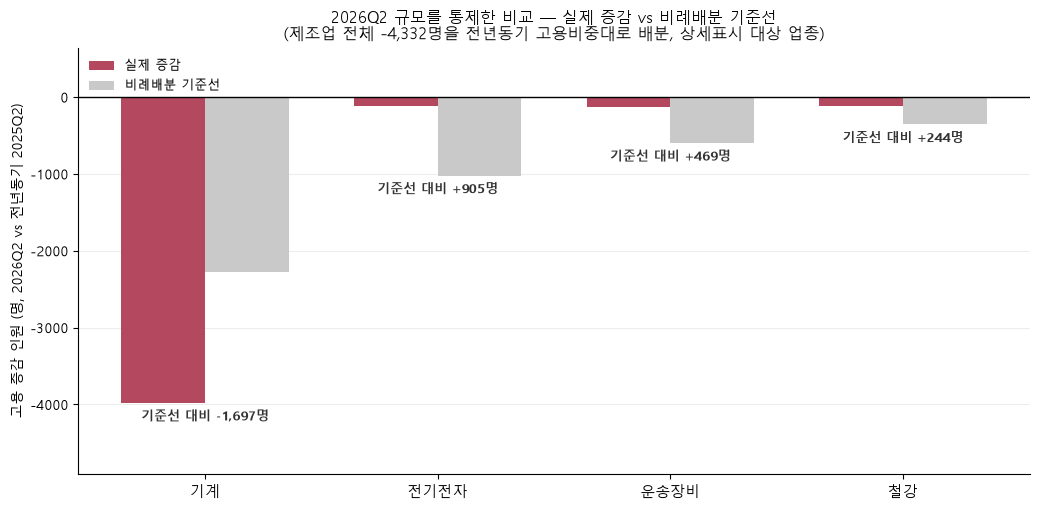

,증감인원,비례기대증감,초과증감,고용비중%
industry,,,,
기계,-3979.0,-2281.7,-1697.3,51.2
전기전자,-116.0,-1021.4,905.4,24.4
운송장비,-129.0,-597.5,468.5,14.2
철강,-112.0,-356.3,244.3,8.4
음식료,-25.0,-24.0,-1.0,0.6
석유화학,54.0,-20.5,74.5,0.5
목재종이,-48.0,-17.3,-30.7,0.4
비금속,-2.0,-6.7,4.7,0.2
기타,25.0,-5.3,30.3,0.1


기준선은 모든 업종이 제조업 전체와 같은 비율로 변했다고 가정한 비교값이다.
초과증감의 원인(채용·감원·업종 구성 차이 등)은 이 자료로 확인할 수 없다.


In [26]:
# ---- Q2-C. 실제 증감 vs 비례배분 기준선 (상세표시 대상 업종) --------------------
if MAIN_IND:
    bl = q2.loc[MAIN_IND, ['증감인원', '비례기대증감', '초과증감']]
    fig, ax = plt.subplots(figsize=(10.5, 5.2))
    x = np.arange(len(bl))
    w = 0.36
    ax.bar(x - w / 2, bl.증감인원, w, label='실제 증감',
           color=[DELTA_COLORS['down'] if v < 0 else (DELTA_COLORS['up'] if v > 0 else DELTA_COLORS['neutral'])
                  for v in bl.증감인원])
    ax.bar(x + w / 2, bl.비례기대증감, w, label='비례배분 기준선', color='#C9C9C9')
    lo = min(bl.증감인원.min(), bl.비례기대증감.min(), 0)
    hi = max(bl.증감인원.max(), bl.비례기대증감.max(), 0)
    pad = (hi - lo) * 0.18 or 1.0
    for xi, (ind, row) in zip(x, bl.iterrows()):
        anchor = min(row.증감인원, row.비례기대증감, 0)
        ax.text(xi, anchor - pad * 0.12, f'기준선 대비 {row.초과증감:+,.0f}명', ha='center', va='top',
                fontsize=9.5, fontweight='bold', color='#333333')
    ax.axhline(0, color='black', lw=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(bl.index, fontsize=10.5)
    ax.set_ylim(lo - pad * 1.3, hi + pad * 0.9)
    ax.set_ylabel(f'고용 증감 인원 (명, {LATEST} vs 전년동기 {BASE_Q})', fontsize=10.2)
    ax.set_title(f'{LATEST} 규모를 통제한 비교 — 실제 증감 vs 비례배분 기준선\n'
                 f'(제조업 전체 {net:+,.0f}명을 전년동기 고용비중대로 배분, 상세표시 대상 업종)', fontsize=11.5)
    ax.legend(loc='upper left', frameon=False, fontsize=9)
    style_ax(ax)
    plt.tight_layout()
    save_fig(fig, 'Q2C_비례기준선_비교')
    plt.show()

display(q2.loc[IND_ORDER_EMP, ['증감인원', '비례기대증감', '초과증감', '고용비중%']].round(1))
print('기준선은 모든 업종이 제조업 전체와 같은 비율로 변했다고 가정한 비교값이다.')
print('초과증감의 원인(채용·감원·업종 구성 차이 등)은 이 자료로 확인할 수 없다.')

## Section 4. Q3 시간 — 국면은 얼마나 이어지고 어떤 경로로 바뀌는가?

같은 국면이 연속된 기간과 인접한 두 분기의 상태를 확인한다.
지속기간은 기존 전처리 정의대로 S1~S4만 집계하고, 인접 전환표에는 N도 포함한다.
결측 구간을 연결하지 않는다. YoY는 비교 기간이 겹치므로 연속된 상태를 독립적인 반복 증거로 취급하지 않는다.

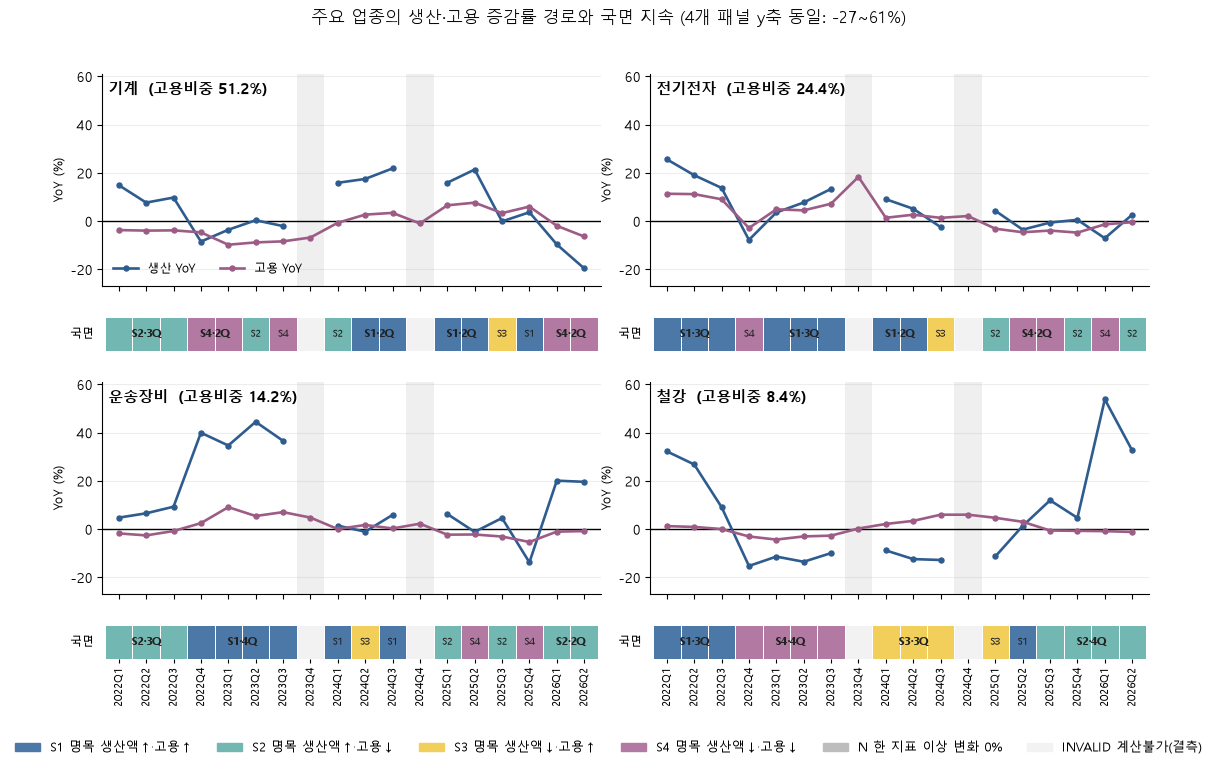

모든 패널의 y축 범위는 같다. 아래 리본은 명목 기준 국면이며 PPI 조정 국면이 아니다.
기계     생산 YoY   -19.5 ~   21.9% | 고용 YoY   -9.7 ~   7.7%
전기전자   생산 YoY    -7.8 ~   25.7% | 고용 YoY   -4.7 ~  18.4%
운송장비   생산 YoY   -13.8 ~   44.5% | 고용 YoY   -5.3 ~   9.1%
철강     생산 YoY   -15.2 ~   53.8% | 고용 YoY   -4.3 ~   6.0%


In [27]:
# ---- Q3-A. 주요 업종의 생산·고용 YoY 경로 + 국면 리본(연속기간) ----------------
sub = state[state.industry.isin(MAIN_IND)]
ymin = min(sub.production_yoy.min(), sub.employment_yoy.min())
ymax = max(sub.production_yoy.max(), sub.employment_yoy.max())
pad = (ymax - ymin) * 0.10
qi_all = sorted(state.quarter_index.unique())
qi2x = {qi: i for i, qi in enumerate(qi_all)}

panel_rows = max(1, int(np.ceil(len(MAIN_IND)/2)))
fig = plt.figure(figsize=(13.5, 3.8*panel_rows))
gs = fig.add_gridspec(panel_rows*2, 2, height_ratios=[1, 0.16]*panel_rows, hspace=0.25, wspace=0.10)
cmap = ListedColormap([STATE_COLORS[s] for s in STATES6])
norm = BoundaryNorm(np.arange(-0.5, len(STATES6) + 0.5, 1), cmap.N)
code_map = {s: i for i, s in enumerate(STATES6)}

for k, ind in enumerate(MAIN_IND):
    r, c = 2*(k//2), k%2
    axl = fig.add_subplot(gs[r, c])
    axb = fig.add_subplot(gs[r + 1, c])

    g = state[state.industry == ind].sort_values('quarter_index')
    xs = [qi2x[v] for v in g.quarter_index]

    axl.axhline(0, color='black', lw=1.0)
    for q_inv in INVALID_QUARTERS:                       # 결측 분기를 옅은 세로띠로 표시
        axl.axvspan(qi2x[g.loc[g.quarter == q_inv, 'quarter_index'].iloc[0]] - 0.5,
                    qi2x[g.loc[g.quarter == q_inv, 'quarter_index'].iloc[0]] + 0.5,
                    color='#EFEFEF', lw=0, zorder=0)
    axl.plot(xs, g.production_yoy, color=SERIES_COLORS['production'], lw=1.9, marker='o', ms=3.6,
             label='생산 YoY')
    axl.plot(xs, g.employment_yoy, color=SERIES_COLORS['employment'], lw=1.9, marker='o', ms=3.6,
             label='고용 YoY')
    axl.set_ylim(ymin - pad, ymax + pad)
    axl.set_xlim(-0.6, len(qi_all) - 0.4)
    axl.set_xticks(range(len(qi_all)))
    axl.set_xticklabels([])
    emp_sh = g.loc[g.quarter == LATEST, 'employment'].iloc[0] / \
        state.loc[state.quarter == LATEST, 'employment'].sum() * 100
    axl.text(0.012, 0.965, f'{ind}  (고용비중 {emp_sh:.1f}%)', transform=axl.transAxes,
             va='top', fontsize=11, fontweight='bold')
    axl.set_ylabel('YoY (%)', fontsize=9.5)
    style_ax(axl)
    if k == 0:
        axl.legend(loc='lower left', frameon=False, fontsize=8.8, ncol=2)

    arr = np.array([[code_map[s] for s in g.state]], dtype=float)
    axb.pcolormesh(np.arange(len(qi_all) + 1) - 0.5, np.array([0.0, 1.0]), arr,
                   cmap=cmap, norm=norm, edgecolors='white', linewidth=0.7)
    axb.set_xlim(axl.get_xlim()); axb.set_yticks([])
    axb.set_xticks(np.arange(len(qi_all)))
    # 분기 라벨은 아래쪽 두 패널에만 — 위 패널 리본의 라벨은 아래 패널 제목과 겹친다
    axb.set_xticklabels(g.quarter if k//2 == panel_rows-1 else [''] * len(qi_all), rotation=90, fontsize=7.6)
    axb.tick_params(axis='x', length=3 if k//2 == panel_rows-1 else 0)
    for sp in axb.spines.values():
        sp.set_visible(False)
    # 연속기간(2분기 이상)를 리본 위에 숫자로 표기 — Q1B 격자가 보여주지 않는 정보
    states_list = g.state.tolist()
    i = 0
    while i < len(states_list):
        s = states_list[i]
        j = i
        while j + 1 < len(states_list) and states_list[j + 1] == s:
            j += 1
        run_len = j - i + 1
        if s in STATES4 and run_len >= 2:
            axb.text((i + j) / 2, 0.5, f'{s}·{run_len}Q', ha='center', va='center',
                     fontsize=7.6, color='#222222', fontweight='bold')
        elif s in STATES4:
            axb.text((i + j) / 2, 0.5, s, ha='center', va='center',
                     fontsize=7.0, color='#222222')
        i = j + 1
    axb.set_ylabel('국면', fontsize=8.5, rotation=0, ha='right', va='center', labelpad=6)

handles = [Rectangle((0, 0), 1, 1, color=STATE_COLORS[k]) for k in STATES6]
fig.legend(handles, [STATE_LABELS[k] for k in STATES6], loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=9)
fig.suptitle(f'주요 업종의 생산·고용 증감률 경로와 국면 지속 ({len(MAIN_IND)}개 패널 y축 동일: '
             f'{ymin - pad:.0f}~{ymax + pad:.0f}%)', fontsize=12, y=0.965)
save_fig(fig, 'Q3A_주요업종_경로')
plt.show()

print('모든 패널의 y축 범위는 같다. 아래 리본은 명목 기준 국면이며 PPI 조정 국면이 아니다.')
for ind in MAIN_IND:
    g = state[state.industry == ind].sort_values('quarter_index')
    print(f'{ind:6s} 생산 YoY {g.production_yoy.min():7.1f} ~ {g.production_yoy.max():6.1f}% | '
          f'고용 YoY {g.employment_yoy.min():6.1f} ~ {g.employment_yoy.max():5.1f}%')

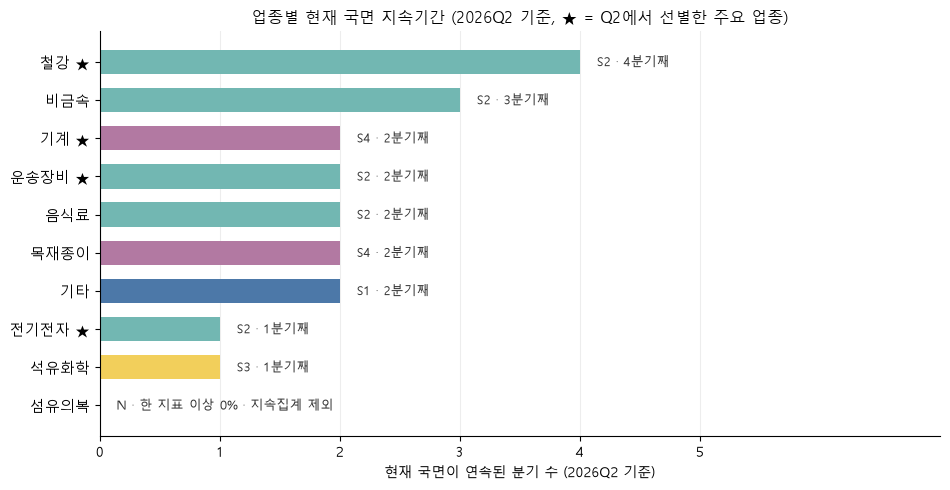

◁ 는 run이 관측 블록의 시작과 함께 시작해 실제 지속기간이 더 길 수 있음을 뜻한다(좌측 절단).
좌측 절단 업종: 없음


In [28]:
# ---- Q3-B. 현재 국면 지속기간 -------------------------------------------------
cur = state[state.quarter == LATEST].set_index('industry').reindex(IND_ORDER_EMP)
_sort_key = pd.DataFrame({'_sort': cur.run_length.fillna(-1),
                          '_share': cur.employment / cur.employment.sum()})
cur = cur.loc[_sort_key.sort_values(['_sort', '_share'], ascending=[False, False]).index]

fig, ax = plt.subplots(figsize=(9.6, 5.0))
y = np.arange(len(cur))
bar_len = cur.run_length.fillna(0)
ax.barh(y, bar_len, color=[STATE_COLORS.get(s, '#BDBDBD') for s in cur.state], height=0.64)
ax.set_yticks(y)
ax.set_yticklabels([f'{i} ★' if i in MAIN_IND else i for i in cur.index], fontsize=10.5)
ax.invert_yaxis()
ax.set_xlabel(f'현재 국면이 연속된 분기 수 ({LATEST} 기준)', fontsize=10.2)
ax.set_xlim(0, bar_len.max() + 3.0)
ax.set_xticks(range(0, int(bar_len.max()) + 2))

for yi, (ind, row) in zip(y, cur.iterrows()):
    if row.state == 'N':
        label = 'N · 한 지표 이상 0% · 지속집계 제외'
    elif row.state == 'INVALID':
        label = '계산 불가 · 지속집계 제외'
    else:
        label = f'{row.state} · {int(row.run_length)}분기째'
    ax.text(bar_len[ind] + 0.14, yi, label, va='center', fontsize=9.3, color='#333333')
    if pd.notna(row.run_left_censored) and bool(row.run_left_censored):
        ax.text(-0.22, yi, '◁', va='center', ha='right', fontsize=11, color='#555555')

ax.set_title(f'업종별 현재 국면 지속기간 ({LATEST} 기준, ★ = Q2에서 선별한 주요 업종)', fontsize=11.5)
style_ax(ax, ygrid=False, xgrid=True)
plt.tight_layout()
save_fig(fig, 'Q3B_현재국면_지속')
plt.show()

print('◁ 는 run이 관측 블록의 시작과 함께 시작해 실제 지속기간이 더 길 수 있음을 뜻한다(좌측 절단).')
print(f'좌측 절단 업종: {cur.index[cur.run_left_censored.fillna(False).astype(bool)].tolist() or "없음"}')

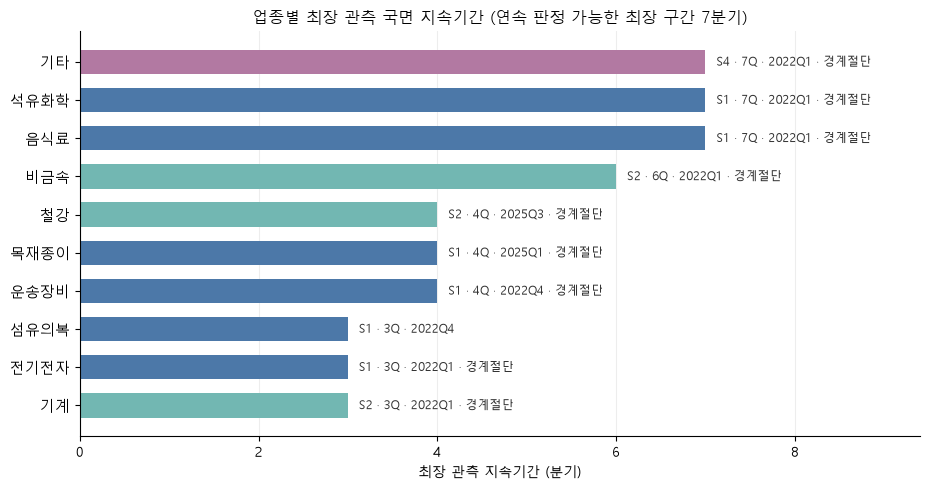

S1~S4 연속구간 70개 중 2분기 이상 39개(55.7%), 평균 2.23분기, 최장 7분기
패널 시작·끝 또는 결측에 닿는 구간은 실제 지속기간이 더 길 수 있다.
연속 판정 가능 구간(INVALID로 나뉜 블록): [7, 3, 6] -> 관측할 수 있는 최장 지속은 7분기
최장 관측값이 이 한계와 같은 업종: 음식료, 석유화학, 기타 — 관측 구간에 막힌 값이므로 실제 길이는 확정할 수 없다.


In [29]:
# ---- Q3-C. 업종별 최장 관측 지속기간 -----------------------------------------
runs = state.dropna(subset=['run_id']).drop_duplicates(['industry', 'run_id'])
share2plus = (runs.run_total_length >= 2).mean() * 100
longest = (runs.sort_values('run_total_length', ascending=False)
           .drop_duplicates('industry').set_index('industry')
           [['state', 'state_start_quarter', 'run_total_length',
             'run_left_censored', 'run_right_censored']]
           .reindex(IND_ORDER_EMP)
           .rename(columns={'state': '국면', 'state_start_quarter': '시작분기',
                            'run_total_length': '지속분기',
                            'run_left_censored': '좌절단', 'run_right_censored': '우절단'}))

# 연속 판정이 가능한 구간(INVALID로 끊기지 않는 분기 블록)의 길이.
# 최장 관측값이 이 블록 길이와 같으면 관측 구간 경계에 막힌 것이므로 실제 길이는 확정할 수 없다.
def valid_block_lengths(g):
    lengths, run = [], 0
    for s in g.sort_values('quarter_index').state:
        if s == 'INVALID':
            if run:
                lengths.append(run)
            run = 0
        else:
            run += 1
    if run:
        lengths.append(run)
    return lengths

_blocks = {ind: valid_block_lengths(g) for ind, g in state.groupby('industry')}
_unique_blocks = {tuple(v) for v in _blocks.values()}
VALID_BLOCKS = list(next(iter(_unique_blocks))) if len(_unique_blocks) == 1 else _blocks
MAX_OBSERVABLE_RUN = int(max(max(v) for v in _blocks.values()))
longest['경계절단'] = longest.좌절단.eq(True) | longest.우절단.eq(True)

long_plot = longest.sort_values(['지속분기', '시작분기'])
fig, ax = plt.subplots(figsize=(9.4, 5.0))
y = np.arange(len(long_plot))
ax.barh(y, long_plot.지속분기, height=0.64,
        color=[STATE_COLORS[s] for s in long_plot.국면])
ax.set_yticks(y)
ax.set_yticklabels(long_plot.index, fontsize=10.5)
ax.set_xlabel('최장 관측 지속기간 (분기)', fontsize=10.2)
ax.set_xlim(0, long_plot.지속분기.max() + 2.4)
for yi, (ind, row) in zip(y, long_plot.iterrows()):
    censor = ' · 경계절단' if bool(row.좌절단) or bool(row.우절단) else ''
    ax.text(row.지속분기 + 0.12, yi,
            f'{row.국면} · {int(row.지속분기)}Q · {row.시작분기}{censor}',
            va='center', fontsize=8.9, color='#333333')
ax.set_title(f'업종별 최장 관측 국면 지속기간 (연속 판정 가능한 최장 구간 {MAX_OBSERVABLE_RUN}분기)', fontsize=11.5)
style_ax(ax, ygrid=False, xgrid=True)
plt.tight_layout()
save_fig(fig, 'Q3C_업종별_최장지속')
plt.show()

print(f'S1~S4 연속구간 {len(runs)}개 중 2분기 이상 '
      f'{int((runs.run_total_length >= 2).sum())}개({share2plus:.1f}%), '
      f'평균 {runs.run_total_length.mean():.2f}분기, 최장 {runs.run_total_length.max():.0f}분기')
print('패널 시작·끝 또는 결측에 닿는 구간은 실제 지속기간이 더 길 수 있다.')
print(f'연속 판정 가능 구간(INVALID로 나뉜 블록): {VALID_BLOCKS} -> 관측할 수 있는 최장 지속은 {MAX_OBSERVABLE_RUN}분기')
_ceiling = longest.index[longest.지속분기.eq(MAX_OBSERVABLE_RUN)].tolist()
if _ceiling:
    print(f'최장 관측값이 이 한계와 같은 업종: {", ".join(_ceiling)} — 관측 구간에 막힌 값이므로 실제 길이는 확정할 수 없다.')


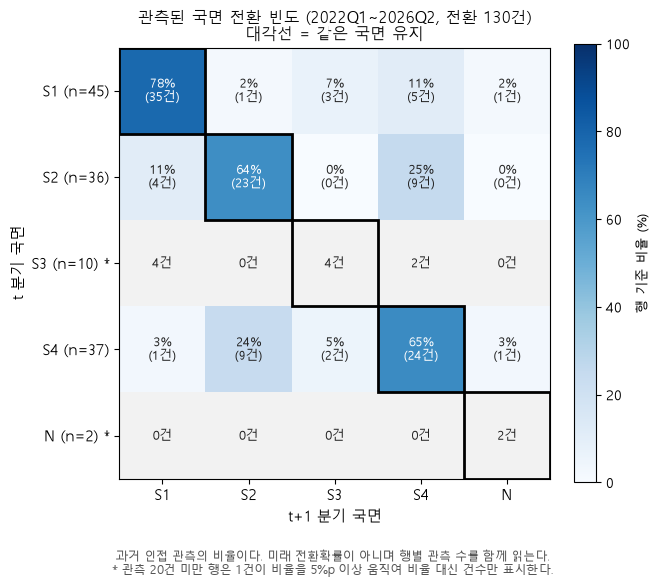

In [30]:
# ---- Q3-C. 관측된 국면 전환 빈도 ---------------------------------------------
trans = state[state.valid_transition5 == True]
mat = pd.crosstab(trans.state, trans.next_state).reindex(index=STATES5, columns=STATES5, fill_value=0)
row_n = mat.sum(axis=1)
mat_pct = mat.div(row_n, axis=0).fillna(0) * 100
diag = sum(mat.loc[s, s] for s in STATES5)
# 행 관측 수가 적으면 한 건이 행 비율을 크게 움직인다(1건 = 100/n %p).
# 한 건이 5%p 이상을 움직이는 행(n < 20)은 비율을 표시하지 않고 건수만 적는다.
TRANSITION_MIN_ROW_N = 20
low_n_rows = [s for s in STATES5 if row_n[s] < TRANSITION_MIN_ROW_N]

fig, ax = plt.subplots(figsize=(6.6, 5.9))
_shown = mat_pct.astype(float).copy()
_shown.loc[low_n_rows] = np.nan
_cmap = plt.get_cmap('Blues').copy()
_cmap.set_bad('#F2F2F2')
im = ax.imshow(np.ma.masked_invalid(_shown.values), cmap=_cmap, vmin=0, vmax=100)
ax.set_xticks(range(5)); ax.set_xticklabels(STATES5, fontsize=10.5)
ax.set_yticks(range(5))
ax.set_yticklabels([f'{s} (n={row_n[s]}){" *" if s in low_n_rows else ""}' for s in STATES5], fontsize=10.5)
ax.set_xlabel('t+1 분기 국면', fontsize=10.5)
ax.set_ylabel('t 분기 국면', fontsize=10.5)
for i in range(5):
    for j in range(5):
        pct, cnt = mat_pct.values[i, j], mat.values[i, j]
        if STATES5[i] in low_n_rows:
            ax.text(j, i, f'{cnt}건', ha='center', va='center', fontsize=9, color='#222222')
        else:
            ax.text(j, i, f'{pct:.0f}%\n({cnt}건)', ha='center', va='center', fontsize=9,
                    color='white' if pct > 55 else '#222222')
    ax.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=2))
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('행 기준 비율 (%)', fontsize=9)
ax.set_title(f'관측된 국면 전환 빈도 ({QUARTERS[0]}~{LATEST}, 전환 {len(trans)}건)\n'
             '대각선 = 같은 국면 유지', fontsize=11.5)
fig.text(0.5, -0.02,
         '과거 인접 관측의 비율이다. 미래 전환확률이 아니며 행별 관측 수를 함께 읽는다.'
         + (f'\n* 관측 {TRANSITION_MIN_ROW_N}건 미만 행은 1건이 비율을 {100 / TRANSITION_MIN_ROW_N:.0f}%p 이상 움직여 비율 대신 건수만 표시한다.'
            if low_n_rows else ''),
         ha='center', fontsize=8.8, color='#555555')
plt.tight_layout()
save_fig(fig, 'Q3C_전환행렬')
plt.show()

results_summary['q3'] = {'n_runs':len(runs), 'n_runs_2plus':int((runs.run_total_length>=2).sum()),
    'share_2plus_pct':float(share2plus), 'mean_run':float(runs.run_total_length.mean()),
    'max_run':int(runs.run_total_length.max()), 'n_adjacent':len(trans), 'n_same':int(diag),
    'same_pct':float(diag/len(trans)*100),
    'transition_min_row_n': TRANSITION_MIN_ROW_N, 'transition_low_n_rows': low_n_rows,
    'valid_block_lengths': VALID_BLOCKS, 'max_observable_run': MAX_OBSERVABLE_RUN,
    'max_run_at_ceiling': bool(runs.run_total_length.max() == MAX_OBSERVABLE_RUN),
    'n_longest_censored': int(longest.경계절단.sum()), 'current':[
        {'industry':i, 'state':r.state, 'length':None if pd.isna(r.run_length) else int(r.run_length)}
        for i,r in cur.iterrows()]}


In [31]:
r = results_summary['q3']
print(f'S1~S4 연속구간 {r["n_runs"]}개 중 두 분기 이상 '
      f'{r["n_runs_2plus"]}개({r["share_2plus_pct"]:.1f}%), 최장 {r["max_run"]}분기')
print(f'N을 포함한 인접 관측 {r["n_adjacent"]}건 중 같은 상태 유지 '
      f'{r["n_same"]}건({r["same_pct"]:.1f}%)')
print('관측 빈도는 미래 전환확률이 아니며 실제 전체 지속기간과 구조적 원인을 확정하지 않는다.')
if r['max_run_at_ceiling']:
    print(f'최장 {r["max_run"]}분기는 연속 판정 가능한 최장 구간({r["max_observable_run"]}분기)과 같다 — 실제 최장 지속은 확정할 수 없다.')
if r['transition_low_n_rows']:
    print(f'행 관측 {r["transition_min_row_n"]}건 미만으로 비율을 표시하지 않은 행: {", ".join(r["transition_low_n_rows"])}')


S1~S4 연속구간 70개 중 두 분기 이상 39개(55.7%), 최장 7분기
N을 포함한 인접 관측 130건 중 같은 상태 유지 88건(67.7%)
관측 빈도는 미래 전환확률이 아니며 실제 전체 지속기간과 구조적 원인을 확정하지 않는다.
최장 7분기는 연속 판정 가능한 최장 구간(7분기)과 같다 — 실제 최장 지속은 확정할 수 없다.
행 관측 20건 미만으로 비율을 표시하지 않은 행: S3, N


## Section 5. 보조분석 — 주요 업종의 가동률·업체수

Q1~Q3를 보완하기 위해 가동률과 업체수의 움직임을 함께 확인한다.
각 지표가 있는 기간만 사용하며, 가동률 수준과 가동업체/입주업체 비율을 구분한다.
고용을 업체수와 업체당 평균 인원으로 나눈 산술 분해는 기업별 고용 원인 분석이 아니다.

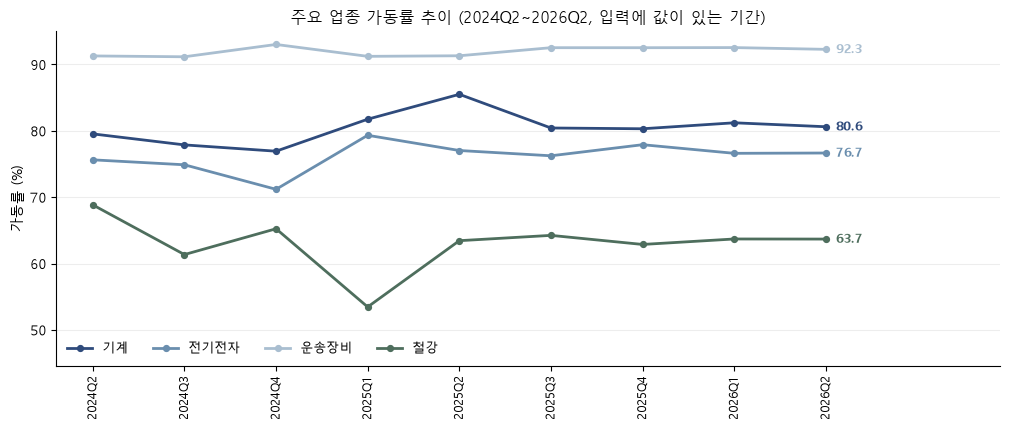

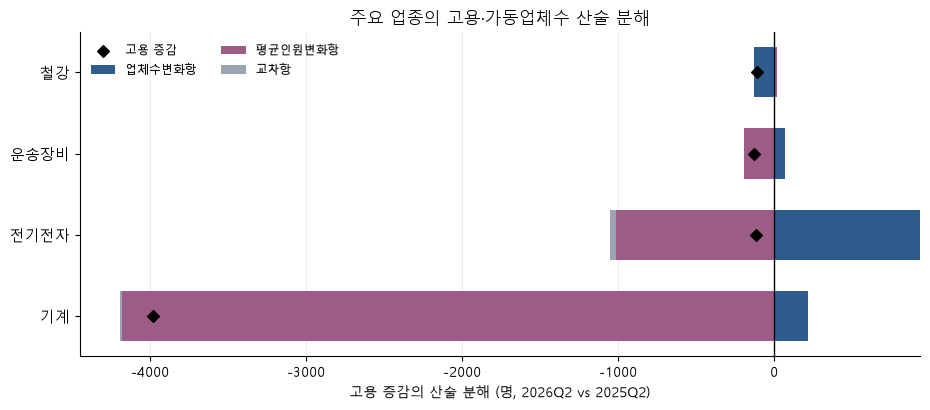

업종 고용/가동업체수는 산술 평균이며 실제 사업장별 진입·퇴출·채용·감원 인원이 아니다.
가동률과 가동업체/입주업체 비율은 서로 다른 지표다.


In [32]:
op = state[state.op_rate_official.notna()]
op_qs = sorted(op.quarter.unique())

fig, ax = plt.subplots(figsize=(10.2, 4.4))
x = np.arange(len(op_qs))
for ind, c in zip(MAIN_IND, MAIN_COLORS):
    g = op[op.industry == ind].set_index('quarter').reindex(op_qs)
    ax.plot(x, g.op_rate_official, color=c, lw=2.0, marker='o', ms=4.2, label=ind)
    ax.annotate(f'{g.op_rate_official.iloc[-1]:.1f}', (x[-1], g.op_rate_official.iloc[-1]),
                xytext=(7, 0), textcoords='offset points', va='center', fontsize=9,
                color=c, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(op_qs, rotation=90, fontsize=8.5)
ax.set_xlim(-0.4, len(op_qs) + 0.9)
ax.set_ylabel('가동률 (%)', fontsize=10.2)
_lo, _hi = ax.get_ylim()
ax.set_ylim(_lo - (_hi - _lo) * 0.16, _hi)     # 좌하단 범례가 선을 가리지 않도록 여백
ax.set_title(f'주요 업종 가동률 추이 ({op_qs[0]}~{op_qs[-1]}, 입력에 값이 있는 기간)', fontsize=11.5)
ax.legend(loc='lower left', frameon=False, fontsize=9, ncol=4)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'S5_보조_가동률추이')
plt.show()

# E = F × (E/F)의 산술 분해. 실제 기업별 고용 흐름 분해가 아니다.
_m = state[state.quarter == LATEST].set_index('industry').reindex(MAIN_IND)
_b = pd.DataFrame({'employment':_m.employment_lag4, 'firms_op':_m.firms_op_lag4})
_epf_b = _b.employment / _b.firms_op.replace(0,np.nan)
_epf_m = _m.employment / _m.firms_op.replace(0,np.nan)
margin = pd.DataFrame({'고용증감':_m.emp_delta, '가동업체_전년':_b.firms_op,
    '가동업체_당분기':_m.firms_op, '업체당_전년':_epf_b, '업체당_당분기':_epf_m})
margin['업체수증감'] = _m.firms_op - _b.firms_op
margin['업체수변화항'] = margin.업체수증감*_epf_b
margin['평균인원변화항'] = _b.firms_op*(_epf_m-_epf_b)
margin['교차항'] = margin.업체수증감*(_epf_m-_epf_b)
assert np.allclose(margin[['업체수변화항','평균인원변화항','교차항']].sum(axis=1),margin.고용증감)
parts = margin[['업체수변화항', '평균인원변화항', '교차항']]
fig, ax = plt.subplots(figsize=(9.4, 4.2))
y = np.arange(len(parts))
left_pos = np.zeros(len(parts)); left_neg = np.zeros(len(parts))
part_colors = [SERIES_COLORS['production'], SERIES_COLORS['employment'], '#9AA5B1']
for col, color in zip(parts.columns, part_colors):
    values = parts[col].values
    pos = np.where(values > 0, values, 0); neg = np.where(values < 0, values, 0)
    ax.barh(y, pos, left=left_pos, color=color, height=0.62, label=col)
    ax.barh(y, neg, left=left_neg, color=color, height=0.62)
    left_pos += pos; left_neg += neg
ax.scatter(margin.고용증감, y, color='black', marker='D', s=36, zorder=4, label='고용 증감')
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y); ax.set_yticklabels(parts.index, fontsize=10.5)
ax.set_xlabel(f'고용 증감의 산술 분해 (명, {LATEST} vs {BASE_Q})')
ax.set_title('주요 업종의 고용·가동업체수 산술 분해')
ax.legend(frameon=False, ncol=2, fontsize=8.8)
style_ax(ax, ygrid=False, xgrid=True)
plt.tight_layout()
save_fig(fig, 'S5_보조_고용업체수_산술분해')
plt.show()
print('업종 고용/가동업체수는 산술 평균이며 실제 사업장별 진입·퇴출·채용·감원 인원이 아니다.')
aux = state[state.quarter == LATEST].set_index('industry').reindex(IND_ORDER_EMP)
aux_tbl = pd.DataFrame({'국면':aux.state, '가동률%':aux.op_rate_official,
    '가동률YoY(%p)':aux.op_rate_official_yoy_pp, '입주업체':aux.firms_in,
    '입주YoY%':aux.firms_in_yoy, '가동업체':aux.firms_op, '가동YoY%':aux.firms_op_yoy,
    '가동업체비율':aux.active_firm_ratio})
print('가동률과 가동업체/입주업체 비율은 서로 다른 지표다.')


In [33]:
_op_valid = state[state.op_rate_official_yoy_pp.notna()]
print(f'가동률 전년동기 차이 계산 범위: {_op_valid.quarter.min()}~{_op_valid.quarter.max()}, '
      f'{len(_op_valid)}건')
print('가동률과 업체수는 보조지표이며 기업별 고용 변화의 원인을 식별하지 않는다.')


가동률 전년동기 차이 계산 범위: 2025Q2~2026Q2, 50건
가동률과 업체수는 보조지표이며 기업별 고용 변화의 원인을 식별하지 않는다.


## Section 6. 보조분석 — PPI · EIS

PPI는 선택한 가격지수에 따라 생산 방향의 해석이 달라지는지 확인한다.
EIS는 범위가 다른 두 고용 통계의 흐름을 함께 읽기 위한 배경자료이며, KICOX의 정확성을 입증하는 정답 자료가 아니다.

### PPI — 선택한 가격지수에 따른 생산 방향 비교

**결정: 후보 매핑은 조건부 민감도 분석에 사용하고, 명목 생산 기준 본분석은 유지한다.**

월별 PPI를 계열 코드별로 선택하고, 세 달이 모두 있는 분기만 산술평균한다.
분기 평균의 전년동기 비율을 구한 후 다음과 같이 조정한다.

$$g_{adj}=100\left[\frac{1+g_{nom}/100}{1+g_{ppi}/100}-1\right]$$

이는 분기 명목 생산액을 분기 평균 PPI로 나눈 값의 YoY와 같다.
월별 생산액 가중치가 없으므로 월별로 조정한 생산액을 합한 결과와 같다고 가정하지 않는다.

- 단일 후보는 해당 지수를 대입한 시나리오다. 1:1 품목 대응이 검증되었다는 뜻이 아니다.
- 복수 후보는 각 지수로 계산한 결과의 최솟값·최댓값을 제시한다. 확률적 신뢰구간이나 실제 조정값의 보장된 범위가 아니다.
- 모든 후보에서 명목과 같은 부호 / 모든 후보에서 반대 부호 / 후보별 부호 차이 / 0% 경계를 구분한다.
- 기타는 대응 범위를 정할 근거가 없어 제외한다. 철강1차제품은 철강 관련 후보로 사용하되 전체 업종 구성의 대표성을 확정하지 않는다.

`confirmed`는 승인 대기 의미가 불명확해 제거한다. `mapping_use='sensitivity_only'`,
`main_analysis_eligible=False`로 분석 역할을 명시한다. `aux_usable` 대신 `sensitivity_eligible`을 사용한다.
각 후보의 자료가 완전할 때만 비교에 포함한다.

한국은행은 PPI를 국내에서 생산되어 국내시장에 출하되는 상품·서비스의 가격지수로 설명한다.
전국 지수의 품목 구성, 내수·수출 범위, 산단의 생산 가중치가 일치한다고 확인되지 않았으므로
이 조정값을 산단의 실제 물량·생산성·정확한 실질생산으로 해석하지 않는다.

참고: [한국은행 물가지수 설명](https://www.bok.or.kr/portal/bbs/B0000216/view.do?menuNo=200134&nttId=165633&pageIndex=)

In [34]:
# PPI 원자료 → 코드별 월 패널 → 완전한 분기 평균 → 달력 기준 YoY
ppi_path = ROOT/'data/raw/ppi/ppi_raw.csv'
record_input(ppi_path, '공유된 PPI 원자료')
raw = pd.read_csv(ppi_path, dtype=str)
raw.columns = raw.columns.str.lstrip('\ufeff')
raw['C1'] = raw.C1.str.strip()
raw['DT'] = pd.to_numeric(raw.DT, errors='coerce')
raw['month'] = pd.to_datetime(raw.PRD_DE, format='%Y%m').dt.to_period('M')
series_keys = ['ORG_ID','TBL_ID','ITM_ID','C1','PRD_SE']
# 코드/명칭은 결과 하드코딩이 아니라 분석에 사용한 입력 매핑이다.
mapping_rows = [
    ('기계','311','기계및장비','분류가 가까운 단일 후보'),
    ('운송장비','312','운송장비','전국 운송장비 전체 후보; 산단 품목 비중 미확인'),
    ('비금속','306','비금속광물제품','분류가 가까운 단일 후보'),
    ('음식료','301','음식료품','분류가 가까운 단일 후보'),
    ('목재종이','303','목재및종이제품','분류가 가까운 단일 후보'),
    ('섬유의복','3021','섬유및의복','가죽을 포함하는 상위 항목 대신 하위 후보'),
    ('철강','3071','철강1차제품','비철금속을 포함하는 상위 지수 대신 철강 후보; 가공품 구성 미확인'),
    ('석유화학','304','석탄및석유제품','품목별 가중치 없이 두 후보를 각각 적용'),
    ('석유화학','305','화학제품','품목별 가중치 없이 두 후보를 각각 적용'),
    ('전기전자','309','컴퓨터전자및광학기기','품목별 가중치 없이 두 후보를 각각 적용'),
    ('전기전자','310','전기장비','품목별 가중치 없이 두 후보를 각각 적용'),
]
ppi_map = pd.DataFrame(mapping_rows, columns=['industry','code_suffix','ppi_item','mapping_reason'])
ppi_map['C1'] = '13102134604ACC_CD.'+ppi_map.code_suffix+'AA'
ppi_map['mapping_use'] = 'sensitivity_only'
ppi_map['main_analysis_eligible'] = False
ppi_map['sensitivity_eligible'] = True
ppi_map['series_level_digits'] = ppi_map.code_suffix.str.len()
ppi_map = pd.concat([ppi_map, pd.DataFrame([{'industry':'기타','mapping_reason':'대응 범위 근거 부족',
    'mapping_use':'excluded','main_analysis_eligible':False,'sensitivity_eligible':False}])], ignore_index=True)
selected_map = ppi_map[ppi_map.sensitivity_eligible]
selected = raw[(raw.ORG_ID.eq('301')) & raw.TBL_ID.eq('DT_404Y014') &
    raw.ITM_ID.eq('13103134604999') & raw.PRD_SE.eq('M') & raw.C1.isin(selected_map.C1)].copy()
assert set(selected.C1) == set(selected_map.C1), 'PPI 코드 누락'
assert not selected.duplicated(series_keys+['month']).any(), '동일 PPI 코드/월 중복: 평균처리 금지'
assert selected.UNIT_NM.str.replace('＝','=').eq('2020=100').all(), '사용 계열 기준연도 혼재'
assert selected.DT.gt(0).all(), 'PPI 결측 또는 0 이하'
name_by_code = selected.groupby('C1').C1_NM.agg(lambda x: set(x))
assert all(name_by_code[r.C1] == {r.ppi_item} for r in selected_map.itertuples()), 'PPI 코드-이름 불일치'
calendar = pd.period_range(raw.month.min(), raw.month.max(), freq='M')
monthly = selected.pivot(index='month', columns='C1', values='DT').reindex(calendar)
monthly_missing = monthly.isna().sum()
# 월이 하나라도 없으면 그 분기는 계산하지 않는다. 빈 월을 보간하지 않는다.
monthly['quarter'] = monthly.index.asfreq('Q')
quarterly = monthly.groupby('quarter').mean()
counts = monthly.groupby('quarter').count()
quarterly = quarterly.where(counts.eq(3))
quarterly = quarterly.reindex(pd.period_range(quarterly.index.min(), quarterly.index.max(), freq='Q'))
# 수준값으로 계산한 조정 생산 YoY와 변화율 공식이 일치하는지도 확인한다.
ppi_level_long = quarterly.rename_axis('quarter').reset_index().melt(id_vars='quarter',var_name='C1',value_name='ppi_level')
ppi_lag_long = quarterly.shift(4).rename_axis('quarter').reset_index().melt(id_vars='quarter',var_name='C1',value_name='ppi_level_lag4')
ppi_level_long = ppi_level_long.merge(ppi_lag_long,on=['quarter','C1'],validate='one_to_one')
ppi_level_long['quarter']=ppi_level_long.quarter.astype(str)
ppi_yoy = (quarterly / quarterly.shift(4) - 1)*100
ppi_yoy.index.name = 'quarter'
ppi_long = ppi_yoy.reset_index().melt(id_vars='quarter',var_name='C1',value_name='ppi_yoy')
ppi_long['quarter'] = ppi_long.quarter.astype(str)
ppi_long = ppi_long.merge(selected_map[['industry','C1','ppi_item']],on='C1',validate='many_to_one')
assert not ppi_long.duplicated(['quarter','industry','C1']).any()
assert ppi_long.loc[ppi_long.quarter < str(quarterly.index[0]+4),'ppi_yoy'].isna().all(), '초기 YoY 오류'
base = state[state.production_yoy.notna() & state.employment_yoy.notna()][
    ['quarter','industry','production_yoy','employment_yoy','state','employment']]
mm = base.merge(ppi_long,on=['quarter','industry'],how='inner',validate='one_to_many')
expected_candidates = selected_map.groupby('industry').size()
complete = mm.groupby(['quarter','industry']).ppi_yoy.count().rename('n_valid').reset_index()
complete['n_expected'] = complete.industry.map(expected_candidates)
complete = complete[complete.n_valid.eq(complete.n_expected)]
mm = mm.merge(complete[['quarter','industry']],on=['quarter','industry'],validate='many_to_one')
mm['adjusted_yoy'] = ((1+mm.production_yoy/100)/(1+mm.ppi_yoy/100)-1)*100
# 0% 입력의 수치오차만 처리한다. 분석 중립구간은 변경하지 않는다.
mm.loc[mm.adjusted_yoy.abs()<1e-10,'adjusted_yoy'] = 0
level_check = mm.merge(ppi_level_long,on=['quarter','C1'],validate='many_to_one').merge(
    state[['quarter','industry','production','production_lag4']],on=['quarter','industry'],validate='many_to_one')
level_yoy = ((level_check.production/(level_check.ppi_level/100))/
             (level_check.production_lag4/(level_check.ppi_level_lag4/100))-1)*100
assert np.allclose(level_yoy,level_check.adjusted_yoy), 'PPI 수준값 공식과 YoY 조정 공식 불일치'

sig = mm.groupby(['quarter','industry','production_yoy','employment_yoy','state'],as_index=False).agg(
    adjusted_lo=('adjusted_yoy','min'), adjusted_hi=('adjusted_yoy','max'),
    ppi_lo=('ppi_yoy','min'), ppi_hi=('ppi_yoy','max'), n_candidates=('C1','nunique'),
    ppi_items=('ppi_item',lambda s:'; '.join(sorted(s.unique()))))
nom = np.sign(sig.production_yoy)
sig['all_same'] = np.sign(sig.adjusted_lo).eq(nom) & np.sign(sig.adjusted_hi).eq(nom)
sig['all_opposite'] = (nom.ne(0) & np.sign(sig.adjusted_lo).eq(-nom) & np.sign(sig.adjusted_hi).eq(-nom))
sig['status'] = np.select([sig.all_same, sig.all_opposite,
    sig.adjusted_lo.lt(0)&sig.adjusted_hi.gt(0)],
    ['모든 후보에서 유지','모든 후보에서 반전','후보별 방향 다름'],default='0% 경계 변화')
sig['adjusted_state'] = [classify(r.adjusted_lo,r.employment_yoy)
    if classify(r.adjusted_lo,r.employment_yoy)==classify(r.adjusted_hi,r.employment_yoy) else '후보별 상이'
    for r in sig.itertuples()]
sig['different'] = ~sig.all_same
ppi_year = sig.assign(year=sig.quarter.str[:4]).groupby('year').agg(
    관측수=('status','size'), 전체후보반전=('all_opposite','sum'),
    후보의존=('status',lambda s:s.eq('후보별 방향 다름').sum()),
    차이관측=('different','sum'))
ppi_year['차이비율%'] = ppi_year.차이관측/ppi_year.관측수*100
latest_all = state[state.quarter.eq(LATEST)].set_index('industry')
latest_sig = sig[sig.quarter.eq(LATEST)].set_index('industry')
# 명목 증가 업종에 한정해서 조정 결과를 찾지 않는다: 음→양의 변화도 포착한다.
comparable_down = latest_sig[latest_sig.employment_yoy.lt(0)]
nom_up = comparable_down[comparable_down.production_yoy.gt(0)]
adj_up = comparable_down[comparable_down.adjusted_lo.gt(0)]
adj_possible_up = comparable_down[comparable_down.adjusted_hi.gt(0)]
emp_den = results_summary['q1_latest']['employment_denominator']
nom_num = float(latest_all.loc[nom_up.index,'employment'].sum())
adj_num = float(latest_all.loc[adj_up.index,'employment'].sum())
possible_num = float(latest_all.loc[adj_possible_up.index,'employment'].sum())
target = base[base.industry.isin(selected_map.industry)]
raw_series = raw[series_keys+['C1_NM']].drop_duplicates()
raw_month_counts=raw.groupby('C1').month.nunique()
raw_incomplete=raw_month_counts[raw_month_counts < len(calendar)]
raw_other_units=raw[raw.UNIT_NM.str.replace('＝','=').ne('2020=100')][['C1_NM','UNIT_NM']].drop_duplicates()
selected_audit=selected_map[['industry','C1','ppi_item','series_level_digits']].copy()
selected_audit['n_months']=selected_audit.C1.map(selected.groupby('C1').month.nunique())
selected_audit['missing_months']=selected_audit.C1.map(monthly_missing)
selected_audit['unit']=selected_audit.C1.map(selected.groupby('C1').UNIT_NM.first())
selected_audit.to_csv(DIR_TAB/'PPI_series_audit.csv',index=False,encoding='utf-8-sig')

results_summary['ppi'] = {
    'raw_rows':len(raw),'raw_series':len(raw_series),'raw_names':raw.C1_NM.nunique(),
    'month_start':str(calendar.min()),'month_end':str(calendar.max()),'n_months':len(calendar),
    'raw_incomplete_series':len(raw_incomplete),'raw_other_units':raw_other_units.to_dict('records'),'selected_series':len(selected_map),'selected_missing_months':int(monthly_missing.sum()),
    'quarter_first':str(quarterly.index.min()),'first_yoy_quarter':ppi_long.dropna(subset=['ppi_yoy']).quarter.min(),
    'n_calendar_quarters':len(QUARTERS),'n_ppi_quarters':ppi_long[ppi_long.quarter.isin(QUARTERS)].dropna(subset=['ppi_yoy']).quarter.nunique(),
    'n_comparable':len(sig),'n_target':len(target),'coverage_pct':len(sig)/len(target)*100,
    'n_industries':sig.industry.nunique(),'n_quarters':sig.quarter.nunique(),
    'n_same':int(sig.all_same.sum()),'n_opposite':int(sig.all_opposite.sum()),
    'n_candidate_dependent':int(sig.status.eq('후보별 방향 다름').sum()),
    'n_zero_boundary':int(sig.status.eq('0% 경계 변화').sum()),'n_different':int(sig.different.sum()),
    'different_pct':float(sig.different.mean()*100),
    'yearly':ppi_year.reset_index().to_dict('records'),
    'employment_denominator':emp_den,'nominal_numerator':nom_num,'adjusted_numerator':adj_num,
    'nominal_share_pct':nom_num/emp_den*100,'adjusted_share_pct':adj_num/emp_den*100,
    'possible_adjusted_share_pct':possible_num/emp_den*100,
    'nominal_up_industries':list(nom_up.index),'adjusted_up_industries':list(adj_up.index),
    'latest_comparable_down_count':len(comparable_down),
    'latest_uncompared_down':latest_all.index[latest_all.employment_yoy.lt(0) & ~latest_all.index.isin(latest_sig.index)].tolist(),
    'latest_rows':latest_sig.reset_index().to_dict('records')}
# 후보 계열별 계산 결과 저장. 본분석 생산값은 유지한다.
ppi_map.to_csv(DIR_TAB/'PPI_candidate_mapping.csv',index=False,encoding='utf-8-sig')
sig.to_csv(DIR_TAB/'PPI_sensitivity.csv',index=False,encoding='utf-8-sig')
ppi_year.to_csv(DIR_TAB/'PPI_by_year.csv',encoding='utf-8-sig')
ppi_long.to_csv(DIR_TAB/'PPI_candidate_quarterly_yoy.csv',index=False,encoding='utf-8-sig')
print(f'사용 후보 {len(selected_map)}계열, 월 결측 {int(monthly_missing.sum())}건.')
display(ppi_year.round(2))

사용 후보 11계열, 월 결측 0건.


,관측수,전체후보반전,후보의존,차이관측,차이비율%
year,,,,,
2022,36,8,3,11,30.56
2023,27,1,1,2,7.41
2024,27,1,1,2,7.41
2025,36,1,1,2,5.56
2026,18,2,0,2,11.11


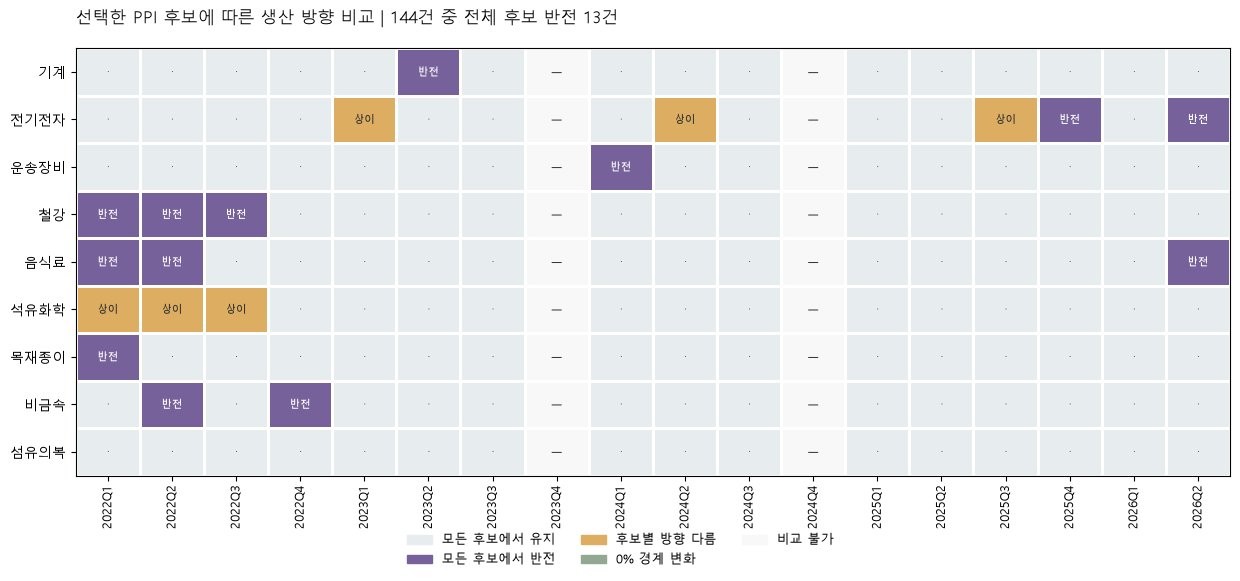

In [35]:
# 그림은 후보에 따라 해석이 달라지는 위치를 보여준다.
IND_PPI=[i for i in IND_ORDER_EMP if i in set(sig.industry)]
PPI_STATUS=['모든 후보에서 유지','모든 후보에서 반전','후보별 방향 다름','0% 경계 변화','비교 불가']
PPI_COLORS=['#E7ECEF','#76619A','#DDAE62','#93A891','#F8F8F8']
ppi_codes={s:i for i,s in enumerate(PPI_STATUS)}
ppi_pivot=sig.pivot(index='industry',columns='quarter',values='status').reindex(index=IND_PPI,columns=QUARTERS).fillna('비교 불가')
ppi_arr=ppi_pivot.apply(lambda col: col.map(ppi_codes)).to_numpy()
fig,ax=plt.subplots(figsize=(12.5,5.5))
ax.pcolormesh(ppi_arr,cmap=ListedColormap(PPI_COLORS),norm=BoundaryNorm(np.arange(-.5,5.5),5),edgecolors='white',linewidth=.8)
for ri in range(len(IND_PPI)):
    for qi in range(len(QUARTERS)):
        value=ppi_arr[ri,qi]
        label={0:'·',1:'반전',2:'상이',3:'0%',4:'—'}[value]
        ax.text(qi+.5,ri+.5,label,ha='center',va='center',fontsize=7.5,color='white' if value==1 else '#333333')
ax.set_xticks(np.arange(len(QUARTERS))+.5,QUARTERS,rotation=90,fontsize=8.5)
ax.set_yticks(np.arange(len(IND_PPI))+.5,IND_PPI,fontsize=10)
ax.invert_yaxis()
r=results_summary['ppi']
ax.set_title(f'선택한 PPI 후보에 따른 생산 방향 비교 | {r["n_comparable"]}건 중 전체 후보 반전 {r["n_opposite"]}건',loc='left',pad=18)
fig.legend([Rectangle((0,0),1,1,color=x) for x in PPI_COLORS],PPI_STATUS,
    loc='lower center',ncol=3,frameon=False,bbox_to_anchor=(.5,-.06),fontsize=9)
plt.tight_layout()
save_fig(fig,'V1_PPI_후보별_방향비교');plt.show()

In [36]:
ppi_display_names={'quarter':'분기','industry':'업종','state':'명목국면','production_yoy':'명목생산YoY(%)',
    'employment_yoy':'고용YoY(%)','ppi_items':'사용후보','ppi_lo':'PPI변화율_최소(%)','ppi_hi':'PPI변화율_최대(%)',
    'adjusted_lo':'조정YoY_최소(%)','adjusted_hi':'조정YoY_최대(%)','status':'후보별방향','adjusted_state':'조정기준국면'}
display(sig.loc[sig.different,['quarter','industry','state','production_yoy','ppi_items',
    'ppi_lo','ppi_hi','adjusted_lo','adjusted_hi','status','adjusted_state']].rename(columns=ppi_display_names).round(2))
display(ppi_map[['industry','C1','ppi_item','mapping_use','main_analysis_eligible','sensitivity_eligible','mapping_reason']].rename(columns={
    'industry':'업종','C1':'항목코드','ppi_item':'후보항목','mapping_use':'사용범위','main_analysis_eligible':'본분석사용',
    'sensitivity_eligible':'민감도사용','mapping_reason':'선택근거와제약'}))

,분기,업종,명목국면,명목생산YoY(%),사용후보,PPI변화율_최소(%),PPI변화율_최대(%),조정YoY_최소(%),조정YoY_최대(%),후보별방향,조정기준국면
1,2022Q1,목재종이,S1,10.39,목재및종이제품,15.02,15.02,-4.02,-4.02,모든 후보에서 반전,S3
3,2022Q1,석유화학,S1,23.23,석탄및석유제품; 화학제품,15.63,63.56,-24.66,6.57,후보별 방향 다름,후보별 상이
6,2022Q1,음식료,S1,3.90,음식료품,5.63,5.63,-1.64,-1.64,모든 후보에서 반전,S3
8,2022Q1,철강,S1,32.27,철강1차제품,36.02,36.02,-2.76,-2.76,모든 후보에서 반전,S3
11,2022Q2,비금속,S2,5.28,비금속광물제품,12.49,12.49,-6.41,-6.41,모든 후보에서 반전,S4
12,2022Q2,석유화학,S1,33.09,석탄및석유제품; 화학제품,15.32,81.99,-26.87,15.41,후보별 방향 다름,후보별 상이
15,2022Q2,음식료,S1,4.57,음식료품,8.08,8.08,-3.25,-3.25,모든 후보에서 반전,S3
17,2022Q2,철강,S1,26.84,철강1차제품,30.22,30.22,-2.59,-2.59,모든 후보에서 반전,S3
21,2022Q3,석유화학,S1,21.39,석탄및석유제품; 화학제품,11.16,55.12,-21.74,9.20,후보별 방향 다름,후보별 상이
26,2022Q3,철강,S1,9.16,철강1차제품,10.49,10.49,-1.20,-1.20,모든 후보에서 반전,S3


,업종,항목코드,후보항목,사용범위,본분석사용,민감도사용,선택근거와제약
0,기계,13102134604ACC_CD.311AA,기계및장비,sensitivity_only,False,True,분류가 가까운 단일 후보
1,운송장비,13102134604ACC_CD.312AA,운송장비,sensitivity_only,False,True,전국 운송장비 전체 후보; 산단 품목 비중 미확인
2,비금속,13102134604ACC_CD.306AA,비금속광물제품,sensitivity_only,False,True,분류가 가까운 단일 후보
3,음식료,13102134604ACC_CD.301AA,음식료품,sensitivity_only,False,True,분류가 가까운 단일 후보
4,목재종이,13102134604ACC_CD.303AA,목재및종이제품,sensitivity_only,False,True,분류가 가까운 단일 후보
5,섬유의복,13102134604ACC_CD.3021AA,섬유및의복,sensitivity_only,False,True,가죽을 포함하는 상위 항목 대신 하위 후보
6,철강,13102134604ACC_CD.3071AA,철강1차제품,sensitivity_only,False,True,비철금속을 포함하는 상위 지수 대신 철강 후보; 가공품 구성 미확인
7,석유화학,13102134604ACC_CD.304AA,석탄및석유제품,sensitivity_only,False,True,품목별 가중치 없이 두 후보를 각각 적용
8,석유화학,13102134604ACC_CD.305AA,화학제품,sensitivity_only,False,True,품목별 가중치 없이 두 후보를 각각 적용
9,전기전자,13102134604ACC_CD.309AA,컴퓨터전자및광학기기,sensitivity_only,False,True,품목별 가중치 없이 두 후보를 각각 적용


In [37]:
r = results_summary['ppi']
first_year = ppi_year.index.min()
a = ppi_year.loc[first_year]
b = ppi_year.drop(first_year)
other_n = int(b.관측수.sum())
other_diff = int(b.차이관측.sum())
other_pct = other_diff / other_n * 100 if other_n else float('nan')

ppi_result = pd.Series({
    '원자료 기간': f'{r["month_start"]}~{r["month_end"]}',
    '선택 후보 계열': r['selected_series'],
    '비교 가능 관측': r['n_comparable'],
    '선택 후보 모두에서 반전': r['n_opposite'],
    '후보별 방향이 다른 관측': r['n_candidate_dependent'],
    '0% 경계 변화': r['n_zero_boundary'],
}, name='값').to_frame()
display(ppi_result)
print(f'{LATEST} 고용 감소·명목 생산액 증가 업종의 고용 합: '
      f'{r["nominal_numerator"]:,.0f}명({r["nominal_share_pct"]:.1f}%); '
      f'선택 후보 모두에서 조정값이 양수인 업종: '
      f'{r["adjusted_numerator"]:,.0f}명({r["adjusted_share_pct"]:.1f}%)')
print(f'두 비율의 분모는 제조업 전체 {r["employment_denominator"]:,.0f}명이다.')
print(f'최신분기 비교 불가 고용 감소 업종: '
      f'{", ".join(r["latest_uncompared_down"]) if r["latest_uncompared_down"] else "없음"}')
print('PPI 결과는 선택 후보의 조건부 비교이며 실제 물량·생산성이나 본분석 국면을 뜻하지 않는다.')

# 최신분기 고용 감소 업종: 명목 기준 국면과 PPI 후보 조정 기준 국면을 나란히 비교한다.
cmp_idx = [i for i in IND_ORDER_EMP
           if i in latest_sig.index and latest_sig.loc[i, 'employment_yoy'] < 0]
latest_cmp = pd.DataFrame({
    '고용비중%': latest_all.loc[cmp_idx, 'employment'] / r['employment_denominator'] * 100,
    '명목생산YoY%': latest_sig.loc[cmp_idx, 'production_yoy'],
    '조정생산YoY_최소%': latest_sig.loc[cmp_idx, 'adjusted_lo'],
    '조정생산YoY_최대%': latest_sig.loc[cmp_idx, 'adjusted_hi'],
    '명목국면': latest_sig.loc[cmp_idx, 'state'],
    '조정기준국면': latest_sig.loc[cmp_idx, 'adjusted_state'],
    '후보별방향': latest_sig.loc[cmp_idx, 'status'],
    '사용후보': latest_sig.loc[cmp_idx, 'ppi_items'],
}, index=pd.Index(cmp_idx, name='업종'))
print()
print(f'{LATEST} 고용 감소 업종의 명목 기준 vs PPI 후보 조정 기준 비교 (고용비중 내림차순)')
display(latest_cmp.round(2))
latest_cmp.to_csv(DIR_TAB / f'PPI_최신분기_명목조정비교_{LATEST}.csv', encoding='utf-8-sig')
print(f'-> outputs/tables/PPI_최신분기_명목조정비교_{LATEST}.csv 저장')


,값
원자료 기간,2021-01~2026-06
선택 후보 계열,11
비교 가능 관측,144
선택 후보 모두에서 반전,13
후보별 방향이 다른 관측,6
0% 경계 변화,0


2026Q2 고용 감소·명목 생산액 증가 업종의 고용 합: 54,794명(47.7%); 선택 후보 모두에서 조정값이 양수인 업종: 26,180명(22.8%)
두 비율의 분모는 제조업 전체 114,830명이다.
최신분기 비교 불가 고용 감소 업종: 없음
PPI 결과는 선택 후보의 조건부 비교이며 실제 물량·생산성이나 본분석 국면을 뜻하지 않는다.

2026Q2 고용 감소 업종의 명목 기준 vs PPI 후보 조정 기준 비교 (고용비중 내림차순)


,고용비중%,명목생산YoY%,조정생산YoY_최소%,조정생산YoY_최대%,명목국면,조정기준국면,후보별방향,사용후보
업종,,,,,,,,
기계,51.19,-19.55,-20.55,-20.55,S4,S4,모든 후보에서 유지,기계및장비
전기전자,24.37,2.70,-15.11,-5.17,S2,S4,모든 후보에서 반전,전기장비; 컴퓨터전자및광학기기
운송장비,14.20,19.64,17.24,17.24,S2,S2,모든 후보에서 유지,운송장비
철강,8.44,32.65,25.28,25.28,S2,S2,모든 후보에서 유지,철강1차제품
음식료,0.55,0.87,-0.78,-0.78,S2,S4,모든 후보에서 반전,음식료품
목재종이,0.37,-12.90,-15.29,-15.29,S4,S4,모든 후보에서 유지,목재및종이제품
비금속,0.16,45.67,40.86,40.86,S2,S2,모든 후보에서 유지,비금속광물제품


-> outputs/tables/PPI_최신분기_명목조정비교_2026Q2.csv 저장


### EIS — 서로 다른 범위의 고용 흐름

KICOX 산단 제조업 고용과 EIS 창원시 제조업 피보험자를 전년동기 대비 방향으로 함께 확인한다.
분기말 인원 자료로 계산하며, 월별 흐름 전체를 확보한 것으로 간주하지 않는다.
수준값을 합산하거나 한 통계를 다른 통계의 정확성 검증 기준으로 쓰지 않는다.

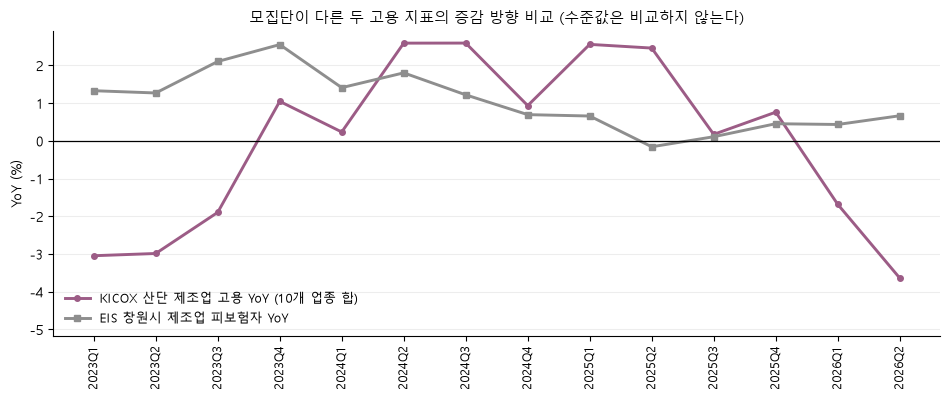

         eis_manufacturing_yoy_pct  kicox_mfg_yoy   부호일치
quarter                                                 
2023Q1                        1.33          -3.04  False
2023Q2                        1.27          -2.99  False
2023Q3                        2.11          -1.89  False
2023Q4                        2.55           1.05   True
2024Q1                        1.41           0.24   True
2024Q2                        1.80           2.59   True
2024Q3                        1.22           2.59   True
2024Q4                        0.70           0.94   True
2025Q1                        0.66           2.56   True
2025Q2                       -0.16           2.46  False
2025Q3                        0.11           0.17   True
2025Q4                        0.46           0.76   True
2026Q1                        0.44          -1.68  False
2026Q2                        0.67          -3.64  False

부호가 일치한 분기: 8 / 14
2026Q2: KICOX -3.6% vs EIS +0.7%
두 지표는 모집단·정의가 달라 수준·점유율을 계산하지 않으며, 

In [38]:
eis_proc_path=DIR_PROC/'eis/eis_validation_panel.csv'
eis_raw_path=ROOT/'data/raw/eis/eis_changwon_insured_2022M03_2026M06.csv'
if eis_proc_path.is_file():
    eis=pd.read_csv(eis_proc_path)
    record_input(eis_proc_path,'기존 EIS 검증 패널')
else:
    eis=pd.read_csv(eis_raw_path,comment='#').sort_values('quarter')
    record_input(eis_raw_path,'공유된 EIS 분기말 인원')
    assert not eis.quarter.duplicated().any()
    es=eis.set_index(pd.PeriodIndex(eis.quarter,freq='Q')).changwon_manufacturing
    es=es.reindex(pd.period_range(es.index.min(),es.index.max(),freq='Q'))
    eis_yoy=(es/es.shift(4)-1)*100
    eis=pd.DataFrame({'quarter':es.index.astype(str),'eis_manufacturing_yoy_pct':eis_yoy.values})
# KICOX는 패널 내부 lag4 합계를 사용해 첫 분석연도의 값을 잃지 않는다.
mfg_yoy=mfg.mfg_emp_delta/lag_mfg*100
merged = (eis[['quarter', 'eis_manufacturing_yoy_pct']]
          .merge(mfg_yoy.rename('kicox_mfg_yoy').reset_index(), on='quarter', how='inner').dropna())

fig, ax = plt.subplots(figsize=(9.6, 4.1))
x = np.arange(len(merged))
ax.plot(x, merged.kicox_mfg_yoy, color=SERIES_COLORS['employment'], lw=2.1, marker='o', ms=4,
        label='KICOX 산단 제조업 고용 YoY (10개 업종 합)')
ax.plot(x, merged.eis_manufacturing_yoy_pct, color='#8E8E8E', lw=2.1, marker='s', ms=4,
        label='EIS 창원시 제조업 피보험자 YoY')
ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(merged.quarter, rotation=90, fontsize=8.5)
ax.set_ylabel('YoY (%)', fontsize=10.2)
_lo, _hi = ax.get_ylim()
ax.set_ylim(_lo - (_hi - _lo) * 0.18, _hi)     # 좌하단 범례가 선을 가리지 않도록 여백
ax.set_title('모집단이 다른 두 고용 지표의 증감 방향 비교 (수준값은 비교하지 않는다)', fontsize=11)
ax.legend(loc='lower left', frameon=False, fontsize=9)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'V2_EIS_YoY비교')
plt.show()

merged['부호일치'] = np.sign(merged.kicox_mfg_yoy) == np.sign(merged.eis_manufacturing_yoy_pct)
print(merged.set_index('quarter').round(2).to_string())
print()
print(f'부호가 일치한 분기: {int(merged.부호일치.sum())} / {len(merged)}')
print(f'{merged.quarter.iloc[-1]}: KICOX {merged.kicox_mfg_yoy.iloc[-1]:+.1f}% vs '
      f'EIS {merged.eis_manufacturing_yoy_pct.iloc[-1]:+.1f}%')
print('두 지표는 모집단·정의가 달라 수준·점유율을 계산하지 않으며, 차이의 원인도 판단할 수 없다.')
results_summary['eis']={'n_comparable':len(merged),'n_same':int(merged.부호일치.sum()),
    'start':merged.quarter.min(),'end':merged.quarter.max()}

## Section 7. 업종별 진단카드

최신분기의 상태·규모·현재 지속기간과 보조지표를 한 표에서 확인한다. 정확한 수치를 함께 읽는 것이 목적이므로 표로 유지하며, Q2 기준에 따라 상세 경로 표시 대상으로 선택된 업종에는 ★를 붙인다. 최근 6분기 경로는 표 너비를 줄이기 위해 아래에 따로 출력한다.


In [39]:
cur = state[state.quarter == LATEST].set_index('industry')
# 최장 지속이 관측 구간 경계에 닿았는지: 시작 = 블록 시작과 함께 시작(더 이전부터 이어졌을 수 있음), 끝 = 블록 끝까지 이어짐
_l, _r = longest.좌절단.eq(True), longest.우절단.eq(True)
longest_censor = pd.Series(np.select([_l & _r, _l, _r], ['시작·끝', '시작', '끝'], default='없음'),
                           index=longest.index)
card = pd.DataFrame({
    '현재국면': cur.state,
    '조정기준국면(PPI)': latest_sig.adjusted_state,
    '생산YoY%': cur.production_yoy,
    '고용YoY%': cur.employment_yoy,
    '고용(명)': cur.employment,
    '고용증감(명)': cur.emp_delta,
    '고용비중%': cur.employment / cur.employment.sum() * 100,
    '현재지속(Q)': cur.run_length,
    '최장지속(Q)': longest.지속분기,
    '최장국면': longest.국면,
    '최장지속_경계절단': longest_censor,
    '가동률%': cur.op_rate_official,
    '가동률YoY(%p)': cur.op_rate_official_yoy_pp,
    '입주업체': cur.firms_in,
    '입주YoY%': cur.firms_in_yoy,
    '가동업체': cur.firms_op,
    '가동YoY%': cur.firms_op_yoy,
}).reindex(IND_ORDER_EMP)
card['조정기준국면(PPI)'] = card['조정기준국면(PPI)'].fillna('비교 불가')
if usable:
    card.insert(card.columns.get_loc('고용비중%') + 1, '기여율%', q2['기여율%'].reindex(IND_ORDER_EMP))
card['최근경로(6Q)'] = [state_path(i, 6, '→') for i in card.index]
card.index = [f'{i} ★' if i in MAIN_IND else i for i in card.index]

print(f'업종별 진단카드 ({LATEST} 기준, ★ = Q2에서 선별한 주요 업종)')
print(card.drop(columns=['최근경로(6Q)']).round(2).to_string())
print()
print('조정기준국면(PPI): 선택 PPI 후보로 조정한 생산 YoY 기준 국면(후보별 결과가 다르면 "후보별 상이"). 본분석 국면은 명목 기준이다.')
print('최장지속_경계절단: 시작/끝/시작·끝이면 관측 구간 경계에 닿아 실제 지속기간이 더 길 수 있다.')
print()
print('최근 6분기 국면 경로:')
for i, p in card['최근경로(6Q)'].items():
    print(f'  {i:9s} {p}')
card.to_csv(DIR_TAB / f'업종별_진단카드_{LATEST}.csv', encoding='utf-8-sig')
print()
print(f'-> outputs/tables/업종별_진단카드_{LATEST}.csv 저장')

업종별 진단카드 (2026Q2 기준, ★ = Q2에서 선별한 주요 업종)
       현재국면 조정기준국면(PPI)  생산YoY%  고용YoY%    고용(명)  고용증감(명)  고용비중%   기여율%  현재지속(Q)  최장지속(Q) 최장국면 최장지속_경계절단   가동률%  가동률YoY(%p)    입주업체  입주YoY%    가동업체  가동YoY%
기계 ★     S4          S4  -19.55   -6.34  58784.0  -3979.0  51.19  91.85      2.0      3.0   S2        시작  80.61       -4.89  1556.0    1.37  1458.0    0.34
전기전자 ★   S2          S4    2.70   -0.41  27979.0   -116.0  24.37   2.68      1.0      3.0   S1        시작  76.65       -0.38   651.0    1.88   590.0    3.33
운송장비 ★   S2          S2   19.64   -0.78  16308.0   -129.0  14.20   2.98      2.0      4.0   S1         끝  92.28        0.97   254.0    0.79   245.0    0.41
철강 ★     S2          S2   32.65   -1.14   9689.0   -112.0   8.44   2.59      4.0      4.0   S2         끝  63.68        0.24    80.0    1.27    74.0   -1.33
음식료      S2          S4    0.87   -3.79    635.0    -25.0   0.55   0.58      2.0      7.0   S1      시작·끝  92.30       -1.43     7.0    0.00     4.0    0.00
석유화학     S3          S3

## Section 8. 핵심 결과와 해석상 주의점

In [40]:
h = results_summary['q1_history']
q1 = results_summary['q1_latest']
q2r = results_summary['q2']
q3r = results_summary['q3']
p = results_summary['ppi']

_ppi_changed = set(p['adjusted_up_industries']) != set(p['nominal_up_industries'])
q1_text = (f"고용 감소 {h['n_down']}건 중 명목 생산액 증가 {h['n_up_down']}건({h['simple_pct']:.1f}%). "
           f"{LATEST} 고용 감소 업종 중 명목 생산액 증가 {len(p['nominal_up_industries'])}개"
           f"(고용비중 {p['nominal_share_pct']:.1f}%) → 선택 PPI 후보 모두에서 조정 생산액 증가 "
           f"{len(p['adjusted_up_industries'])}개({p['adjusted_share_pct']:.1f}%)")
q1_scope = ('같은 고용 방향에서도 명목 생산액 방향은 다를 수 있다. '
            + ('최신분기 결과는 가격 조정 여부에 따라 달라진다.' if _ppi_changed
               else '최신분기 결과는 선택 PPI 후보로 조정해도 유지된다.'))
q2_text = (f"{LATEST} 고용 전년동기 증감 {q2r['net_delta']:+,.0f}명, 최대 감소 "
           f"{', '.join(q2r['largest_decrease_industries'])}. 규모 비례 기준선 대비 초과 감소가 가장 큰 업종 "
           f"{q2r['baseline_max_excess_decrease_industry']} {q2r['baseline_max_excess_decrease']:+,.0f}명")
q2_scope = ('증감률과 실제 인원 규모를 함께 읽는다. '
            '기준선은 모든 업종이 같은 비율로 변했다는 가정의 비교값이며 원인을 뜻하지 않는다.')
q3_ceiling = (f" — 연속 판정 가능한 최장 구간({q3r['max_observable_run']}분기)과 같아 실제 길이는 확정할 수 없음"
              if q3r['max_run_at_ceiling'] else '')
q3_text = (f"최장 관측 {q3r['max_run']}분기{q3_ceiling}, 인접 유지 {q3r['n_same']}/{q3r['n_adjacent']}건"
           f"({q3r['same_pct']:.1f}%)")
q3_scope = '관측된 지속·전환이며 실제 전체 기간이나 미래 확률이 아니다.'
if q3r['transition_low_n_rows']:
    q3_scope += (f" 관측 {q3r['transition_min_row_n']}건 미만 행({', '.join(q3r['transition_low_n_rows'])})은 "
                 '전환 비율을 해석하지 않는다.')

final_summary_text = f"""### Q1·Q2·Q3 요약

| 질문 | 이번 계산에서 확인한 것 | 해석 범위 |
|---|---|---|
| Q1 상태 | {q1_text} | {q1_scope} |
| Q2 규모 | {q2_text} | {q2_scope} |
| Q3 시간 | {q3_text} | {q3_scope} |

PPI 비교 {p['n_comparable']}건 중 선택 후보 모두에서 반전 {p['n_opposite']}건, 후보별 방향 차이 {p['n_candidate_dependent']}건이다. 본분석은 명목 기준을 유지한다. 자동화·인력부족·정책효과 등 원인은 이 자료만으로 확인할 수 없다.
"""
display(Markdown(final_summary_text))

report_text = "\n".join([
    '# EDA 실행 결과',
    '',
    '## 분석 결정',
    '',
    '- 본분석 국면은 KICOX 명목 생산액 YoY와 고용 YoY로 계산한다.',
    '- PPI는 선택 후보에 한정한 민감도 분석이며 실제 물량이나 생산성을 뜻하지 않는다.',
    '- EIS는 모집단이 다른 고용 지표의 방향 비교이며 KICOX 정확성 검증이 아니다.',
    '',
    '## 핵심 결과',
    '',
    final_summary_text.replace('### Q1·Q2·Q3 요약', '').strip(),
    '',
    '## PPI 보조분석',
    '',
    f'- 원자료 {p["month_start"]}~{p["month_end"]}, 선택 후보 {p["selected_series"]}계열.',
    f'- 비교 {p["n_comparable"]}건 중 선택 후보 모두에서 반전 {p["n_opposite"]}건, 후보별 방향 차이 {p["n_candidate_dependent"]}건.',
    '- 선택 후보 결과를 모든 가능한 매핑으로 일반화하지 않으며 본분석 국면을 대체하지 않는다.',
])

(DIR_REPORT/'EDA_revision_report.md').write_text(report_text, encoding='utf-8')
(DIR_TAB/'results_summary.json').write_text(
    json.dumps(results_summary, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
pd.DataFrame(input_audit).to_csv(DIR_TAB/'input_provenance.csv', index=False, encoding='utf-8-sig')
verification_scope.to_csv(DIR_TAB/'verification_scope.csv', index=False, encoding='utf-8-sig')


### Q1·Q2·Q3 요약

| 질문 | 이번 계산에서 확인한 것 | 해석 범위 |
|---|---|---|
| Q1 상태 | 고용 감소 89건 중 명목 생산액 증가 43건(48.3%). 2026Q2 고용 감소 업종 중 명목 생산액 증가 5개(고용비중 47.7%) → 선택 PPI 후보 모두에서 조정 생산액 증가 3개(22.8%) | 같은 고용 방향에서도 명목 생산액 방향은 다를 수 있다. 최신분기 결과는 가격 조정 여부에 따라 달라진다. |
| Q2 규모 | 2026Q2 고용 전년동기 증감 -4,332명, 최대 감소 기계. 규모 비례 기준선 대비 초과 감소가 가장 큰 업종 기계 -1,697명 | 증감률과 실제 인원 규모를 함께 읽는다. 기준선은 모든 업종이 같은 비율로 변했다는 가정의 비교값이며 원인을 뜻하지 않는다. |
| Q3 시간 | 최장 관측 7분기 — 연속 판정 가능한 최장 구간(7분기)과 같아 실제 길이는 확정할 수 없음, 인접 유지 88/130건(67.7%) | 관측된 지속·전환이며 실제 전체 기간이나 미래 확률이 아니다. 관측 20건 미만 행(S3, N)은 전환 비율을 해석하지 않는다. |

PPI 비교 144건 중 선택 후보 모두에서 반전 13건, 후보별 방향 차이 6건이다. 본분석은 명목 기준을 유지한다. 자동화·인력부족·정책효과 등 원인은 이 자료만으로 확인할 수 없다.


### 해석할 때 지킬 기준

- 국면은 명목 금액과 고용의 방향 분류이며 업종의 우열을 나타내지 않는다.
- PPI 후보별 결과는 산단 실제 가격·물량의 보장된 범위가 아니다.
- 전환 빈도는 과거 인접 관측의 비율이며 예측확률이 아니다.
- 관측기간 시작·끝과 결측 구간 때문에 실제 지속기간 전체는 확정할 수 없다.
- 데이터가 바뀌면 결과표·차트·f-string 문구를 함께 다시 실행한다. 별도 검증을 완료하지 못한 자료는 검증 완료로 표시하지 않는다.